# LAB 3: Anomaly Detection & Event Intelligence cho Hydroponics System

"""
Dataset: Hydroponics IoT sensor data (temp, humidity, pH, EC, water_temp, light, co2)

Notebook này nối tiếp Lab 2 theo ranh giới rất rõ:

Lab 2 = Data Pipeline
Telemetry thô → schema/cleaning/feature → baseline model → API /predict

Lab 3 = Event Pipeline
Clean telemetry → anomaly_score → event_type → severity → decision → API /detect-anomaly
"""

> Ghi nhớ: trong AIoT, `anomaly_score` chưa phải quyết định cuối cùng. Kết quả model cần đi qua event layer, severity và safety rule trước khi cảnh báo hoặc điều khiển thiết bị.

## 0. Chuẩn bị môi trường

Chạy các lệnh sau ở terminal trước khi mở notebook:

```bash
python -m venv .venv
.venv\Scripts\activate        # Windows
source .venv/bin/activate       # macOS/Linux
pip install -r requirements.txt
```

**Cần quan sát**  
Nếu cell import bên dưới chạy không lỗi, nghĩa là môi trường đã sẵn sàng.

In [2]:
import sys
from pathlib import Path

# Xác định đường dẫn gốc của project
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Thêm đường dẫn vào sys.path
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Force reload utils module nếu đã import trước đó
if 'utils' in sys.modules:
    del sys.modules['utils']

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Import từ utils
try:
    from utils import (
        load_dataset, add_time_features, time_split, build_events, evaluate_detection,
        infer_sensor_columns, MODEL_DIR, OUTPUT_DIR, make_windows, save_json, normalize_scores
    )
    print("✅ Import thành công từ utils.py")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print(f"Current sys.path: {sys.path}")
    print(f"Checking if utils.py exists at: {src_path / 'utils.py'}")
    import os
    if os.path.exists(src_path / "utils.py"):
        print("✅ utils.py found at", src_path / "utils.py")
        # Read and print first few lines to verify content
        with open(src_path / "utils.py", "r") as f:
            content = f.read()
            if "infer_sensor_columns" in content:
                print("✅ infer_sensor_columns function found in utils.py")
            else:
                print("❌ infer_sensor_columns NOT found in utils.py")
    else:
        print("❌ utils.py not found at", src_path / "utils.py")
    raise

from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Tạo thư mục
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

print("\n" + "="*50)
print("Project root:", PROJECT_ROOT)
print("Output directory:", OUTPUT_DIR)
print("Model directory:", MODEL_DIR)
print("Figures directory:", FIG_DIR)
print("Môi trường đã sẵn sàng.")
print("="*50)

# Kiểm tra functions có sẵn
print("\n✅ Các functions đã import thành công:")
print(f"  - load_dataset: {callable(load_dataset)}")
print(f"  - infer_sensor_columns: {callable(infer_sensor_columns)}")
print(f"  - add_time_features: {callable(add_time_features)}")
print(f"  - build_events: {callable(build_events)}")
print(f"  - evaluate_detection: {callable(evaluate_detection)}")

✅ Import thành công từ utils.py

Project root: /home/vinh_shindo/AIoT/Tuan3
Output directory: /home/vinh_shindo/AIoT/Tuan3/outputs
Model directory: /home/vinh_shindo/AIoT/Tuan3/models
Figures directory: /home/vinh_shindo/AIoT/Tuan3/figures
Môi trường đã sẵn sàng.

✅ Các functions đã import thành công:
  - load_dataset: True
  - infer_sensor_columns: True
  - add_time_features: True
  - build_events: True
  - evaluate_detection: True


## 1. Nạp dataset public

Dataset: Hydroponics IoT sensor data từ Kaggle
Bao gồm các chỉ số: nhiệt độ, độ ẩm, pH, EC (độ dẫn điện), 
nhiệt độ nước, cường độ ánh sáng, CO2

Các file đã tải:
- cleaned_data_IsDefault_Interpolate (đã làm sạch, có interpolate)
- IoTData_25K_with_interpolation (25K dòng, có interpolation)
- IoTData_25K_without_interpolation (25K dòng, không interpolation)
- IoTData_IsDefaultInterpolate (có interpolate mặc định)
- IoTData --Raw-- (dữ liệu thô)

Sẽ tự động chọn file phù hợp nhất.

Notebook có thể chạy theo 2 cách:
1. Nếu đã chạy `python src/download_data.py`, notebook dùng dữ liệu đã tải.
2. Nếu chưa tải được, notebook dùng file sample đi kèm để vẫn học được pipeline.

**Vì sao AIoT cần bước này?**  
Trước khi nói đến model, ta phải biết dữ liệu đến từ đâu, trường nào là timestamp, trường nào là giá trị cảm biến, nhãn anomaly có hay không.

In [3]:
import sys
import os
from pathlib import Path

# Đảm bảo đang ở thư mục gốc project
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Chuyển đến thư mục gốc
os.chdir(PROJECT_ROOT)
print(f"Current working directory: {os.getcwd()}")

# Kiểm tra file data
data_dir = PROJECT_ROOT / "data"
print(f"Data directory: {data_dir}")
print(f"Data directory exists: {data_dir.exists()}")

if data_dir.exists():
    csv_files = list(data_dir.glob("*.csv"))
    print(f"CSV files found: {[f.name for f in csv_files]}")
else:
    print("⚠️ Thư mục data chưa tồn tại, đang tạo...")
    data_dir.mkdir(exist_ok=True)

# Kiểm tra measurements.csv
measurements_file = data_dir / "measurements.csv"

if not measurements_file.exists():
    print("\n📥 measurements.csv chưa tồn tại, đang xử lý dataset...")
    
    # Chạy script download_data
    import subprocess
    result = subprocess.run([
        sys.executable, 
        str(PROJECT_ROOT / "src" / "download_data.py"), 
        "--auto"
    ], cwd=str(PROJECT_ROOT), capture_output=True, text=True)
    
    print(result.stdout)
    if result.returncode != 0:
        print("❌ Lỗi khi xử lý dataset:")
        print(result.stderr)
        
        # Hướng dẫn thủ công
        print("\n📥 HƯỚNG DẪN THỦ CÔNG:")
        print(f"1. Đảm bảo file CSV đã được giải nén vào thư mục: {data_dir}")
        print("2. Chạy lệnh sau trong terminal:")
        print(f"   cd {PROJECT_ROOT}")
        print("   python src/download_data.py --auto")
        raise Exception("Không thể xử lý dataset tự động")
else:
    print(f"✅ Đã tìm thấy measurements.csv tại {measurements_file}")

# Thêm đường dẫn src vào sys.path
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Import utils và load dataset
from utils import load_dataset, infer_sensor_columns

# Load dataset
df = load_dataset()

print("\n" + "="*60)
print("✅ ĐÃ TẢI DATASET THÀNH CÔNG")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Thời gian: {df['created_at'].min()} → {df['created_at'].max()}")
print(f"Số node: {df['node_id'].nunique()}")

print("\n📋 5 dòng đầu tiên:")
print(df.head())

print("\n📋 Thông tin các cột:")
print(df.dtypes)

print(f"\n🏷️ Số điểm anomaly: {int(df['label'].sum()):,}")
print(f"📈 Tỷ lệ anomaly: {df['label'].mean()*100:.2f}%")

# Hiển thị các sensor có sẵn
sensor_cols = infer_sensor_columns(df)
sensor_cols = [col for col in sensor_cols if col not in ['id', 'ID', 'isDefault', 'IsDefault']]
print(f"📊 Đã loại bỏ ID, còn {len(sensor_cols)} sensors: {sensor_cols}")
print(f"\n🔍 Các sensor có trong dataset: {sensor_cols}")

# Thống kê nhanh
print("\n📊 Thống kê nhanh các sensor:")
for sensor in sensor_cols[:5]:
    print(f"  {sensor.upper()}:")
    print(f"    Min: {df[sensor].min():.2f}")
    print(f"    Max: {df[sensor].max():.2f}")
    print(f"    Mean: {df[sensor].mean():.2f}")
    print(f"    Std: {df[sensor].std():.2f}")

Current working directory: /home/vinh_shindo/AIoT/Tuan3
Data directory: /home/vinh_shindo/AIoT/Tuan3/data
Data directory exists: True
CSV files found: ['measurements.csv', 'sample_measurements.csv', 'ambient_temperature_system_failure.csv', 'ambient_temperature_system_failure_labeled.csv', 'IoTData_25K_without_interpolation_2025-05-29 10-24-09.csv', 'sample_ambient_temperature_system_failure.csv', 'IoTData_25K_with_interpolation_2025-05-29 11-42-45.csv', 'cleaned_data_IsDefault_Interpolate.csv', 'IoTData_IsDefaultInterpolate_2025-05-29 10-23-08.csv', 'IoTData --Raw--.csv']
✅ Đã tìm thấy measurements.csv tại /home/vinh_shindo/AIoT/Tuan3/data/measurements.csv

✅ ĐÃ TẢI DATASET THÀNH CÔNG
Dataset shape: (50570, 16)
Thời gian: 2024-01-01 00:00:00 → 2029-10-08 01:00:00
Số node: 1

📋 5 dòng đầu tiên:
   id   ph    TDS  water_level  DHT_temp  DHT_humidity  water_temp pH_reducer  \
0   1  7.0  500.0          0.0      25.5          60.0        20.0         ON   
1   2  7.0  500.0          0.0  

## 2. Quan sát chuỗi thời gian

Trước khi train model, việc đầu tiên và quan trọng nhất là VISUALIZATION.
Nhìn vào dữ liệu giúp chúng ta:

1. PHÁT HIỆN PATTERN:
   - Chu kỳ ngày/đêm (temperature, light thường có chu kỳ 24h)
   - Xu hướng tăng/giảm theo thời gian
   - Mùa vụ trong dữ liệu

2. NHẬN DIỆN ANOMALY:
   - Anomaly là điểm đơn lẻ (point anomaly) hay đoạn dài (collective anomaly)?
   - Có sensor nào bất thường cùng lúc không (correlated anomaly)?
   - Anomaly có tuân theo quy luật nào không?

3. PHÁT HIỆN VẤN ĐỀ DỮ LIỆU:
   - Missing values (khoảng trống trong dữ liệu)
   - Sensor bị stuck (đường thẳng nằm ngang)
   - Noise quá lớn hoặc quá nhỏ

4. XÁC ĐỊNH THAM SỐ CHO MODEL:
   - Cần rolling window size bao nhiêu?
   - Cần threshold thế nào cho phù hợp?
   - Feature engineering nên tập trung vào đặc trưng gì?

📊 Có 5 sensors cần hiển thị: ['ph', 'TDS', 'water_level', 'DHT_temp', 'water_temp']

🎨 Đang vẽ biểu đồ chuỗi thời gian...


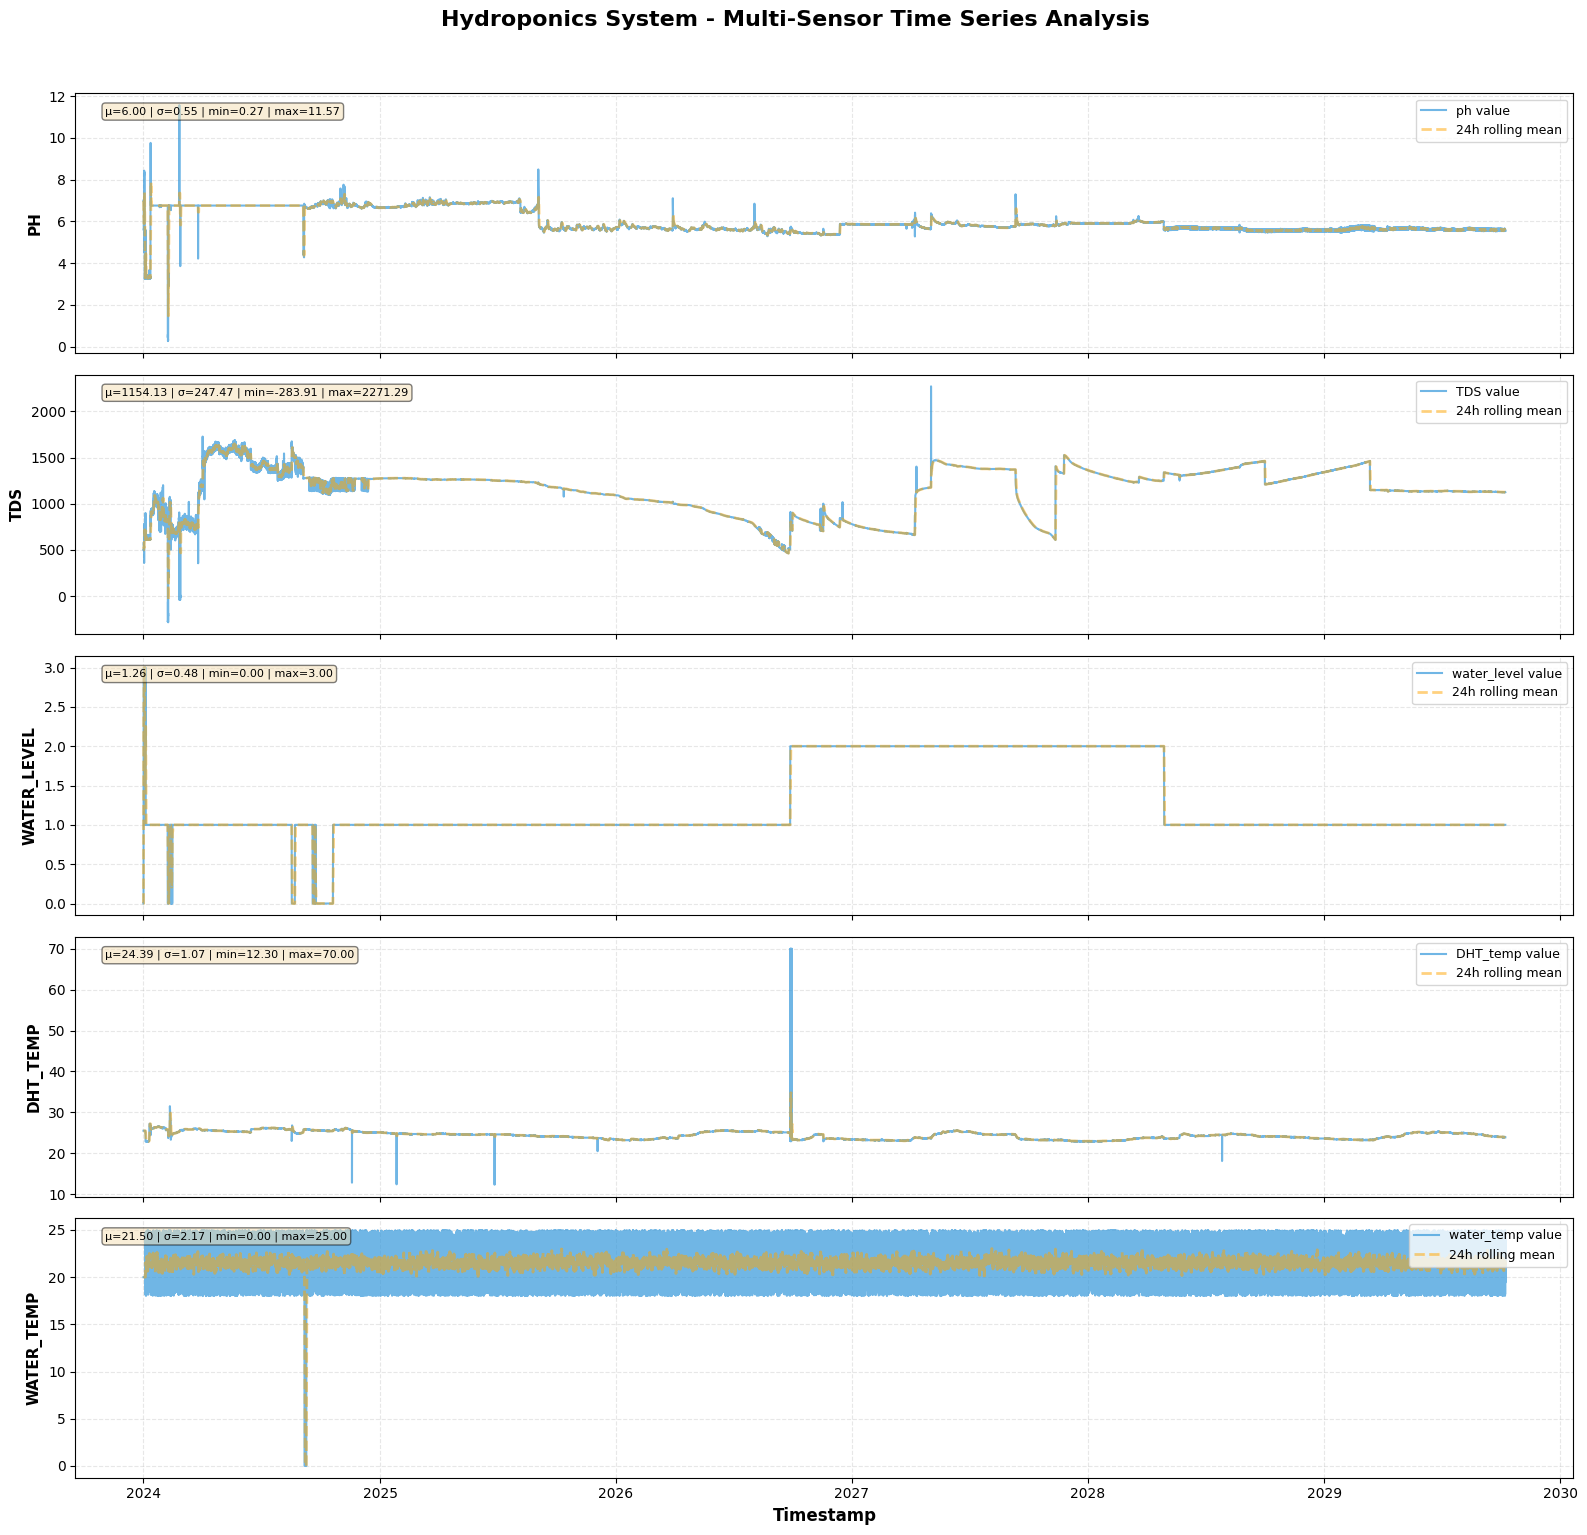


📊 PHÂN TÍCH BAN ĐẦU - TRẢ LỜI CÁC CÂU HỎI

1️⃣ CHU KỲ DỮ LIỆU:
   - Dữ liệu có biến động theo chu kỳ ngày/đêm không?
   • PH: Cao nhất vào 1:00, thấp nhất vào 17:00
     → Không có chu kỳ 24h rõ ràng
   • TDS: Cao nhất vào 9:00, thấp nhất vào 17:00
     → Không có chu kỳ 24h rõ ràng
   • WATER_LEVEL: Cao nhất vào 3:00, thấp nhất vào 1:00
     → Không có chu kỳ 24h rõ ràng

2️⃣ ĐẶC ĐIỂM ANOMALY:
   ⚠️ Không có label anomaly trong dataset

3️⃣ TƯƠNG QUAN GIỮA CÁC SENSOR:
   Các cặp sensor có tương quan cao nhất:
   • PH ↔ DHT_TEMP: 0.382 (tương quan trung bình)
   • WATER_LEVEL ↔ DHT_TEMP: 0.379 (tương quan trung bình)
   • PH ↔ TDS: 0.312 (tương quan trung bình)

4️⃣ PHÁT HIỆN VẤN ĐỀ DỮ LIỆU:
   ✅ Không có missing values trong dữ liệu sensor
   ✅ Tất cả các sensor hoạt động bình thường

5️⃣ KHUYẾN NGHỊ CHO MODEL:
   • Window size đề xuất: 24 (1 ngày) hoặc 12 (nửa ngày)
   • Ưu tiên features: rolling statistics, delta changes, z-score
   • Threshold nên bắt đầu từ percentile 95-96 của a

In [4]:
# Kiểm tra số lượng sensor (loại bỏ các cột không phải sensor)
print(f"📊 Có {len(sensor_cols)} sensors cần hiển thị: {sensor_cols}")
print("\n🎨 Đang vẽ biểu đồ chuỗi thời gian...")

# Điều chỉnh kích thước figure dựa trên số lượng sensor
fig_height = max(3 * len(sensor_cols), 8)  # Tối thiểu 8 inches
fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(16, fig_height), sharex=True)

# Đảm bảo axes là list (xử lý trường hợp chỉ có 1 sensor)
if len(sensor_cols) == 1:
    axes = [axes]

# Vẽ từng sensor
for idx, sensor in enumerate(sensor_cols):
    # Vẽ đường dữ liệu chính
    axes[idx].plot(df["created_at"], df[sensor], 
                   label=f"{sensor} value", 
                   linewidth=1.5, 
                   alpha=0.7,
                   color='#3498db')
    
    # Đánh dấu các điểm anomaly (nếu có)
    if "label" in df.columns and df["label"].sum() > 0:
        anomalies = df[df["label"] == 1]
        axes[idx].scatter(anomalies["created_at"], anomalies[sensor], 
                         color='red', 
                         label=f"known anomaly ({len(anomalies)} points)", 
                         s=40, 
                         zorder=5, 
                         alpha=0.7,
                         marker='^')
    
    # Thêm đường trung bình động để thấy xu hướng
    rolling_mean = df[sensor].rolling(window=24, min_periods=1).mean()
    axes[idx].plot(df["created_at"], rolling_mean, 
                   label=f"24h rolling mean", 
                   linewidth=2, 
                   alpha=0.5,
                   color='orange',
                   linestyle='--')
    
    # Tùy chỉnh đồ thị cho từng sensor
    axes[idx].set_ylabel(sensor.upper(), fontsize=11, fontweight='bold')
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].grid(True, alpha=0.3, linestyle='--')
    
    # Thêm thống kê nhanh vào góc trái của mỗi subplot
    stats_text = f"μ={df[sensor].mean():.2f} | σ={df[sensor].std():.2f} | min={df[sensor].min():.2f} | max={df[sensor].max():.2f}"
    axes[idx].text(0.02, 0.95, stats_text, 
                   transform=axes[idx].transAxes, 
                   fontsize=8, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Label cho trục x
axes[-1].set_xlabel("Timestamp", fontsize=12, fontweight='bold')

# Tiêu đề chính
plt.suptitle("Hydroponics System - Multi-Sensor Time Series Analysis", 
             fontsize=16, 
             fontweight='bold', 
             y=1.02)

# Điều chỉnh layout
plt.tight_layout()

# Lưu figure
plt.savefig(FIG_DIR / "hydroponics_time_series.png", dpi=160, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("📊 PHÂN TÍCH BAN ĐẦU - TRẢ LỜI CÁC CÂU HỎI")
print("="*70)

# Phân tích tự động
print("\n1️⃣ CHU KỲ DỮ LIỆU:")
print("   - Dữ liệu có biến động theo chu kỳ ngày/đêm không?")

# Tạo bản sao tạm thời để phân tích (không ảnh hưởng đến df gốc)
df_analysis = df.copy()
df_analysis['hour'] = pd.to_datetime(df_analysis['created_at']).dt.hour

for sensor in sensor_cols[:3]:  # Phân tích 3 sensor đầu
    # Tính correlation với hour trong ngày
    hourly_mean = df_analysis.groupby('hour')[sensor].mean()
    max_hour = hourly_mean.idxmax()
    min_hour = hourly_mean.idxmin()
    print(f"   • {sensor.upper()}: Cao nhất vào {max_hour}:00, thấp nhất vào {min_hour}:00")
    
    # Kiểm tra tính chu kỳ
    if abs(max_hour - min_hour) in [12, 11, 13]:
        print(f"     → Có chu kỳ 24h rõ rệt (đỉnh và đáy cách nhau ~12h)")
    else:
        print(f"     → Không có chu kỳ 24h rõ ràng")

print("\n2️⃣ ĐẶC ĐIỂM ANOMALY:")
if df["label"].sum() > 0:
    # Phân tích duration của anomaly
    anomaly_points = df[df["label"] == 1]
    print(f"   • Tổng số điểm anomaly: {len(anomaly_points)} ({df['label'].mean()*100:.2f}%)")
    
    # Tìm các đoạn anomaly liên tiếp
    anomaly_blocks = []
    current_block = []
    for idx, row in df.iterrows():
        if row['label'] == 1:
            current_block.append(idx)
        elif current_block:
            anomaly_blocks.append(current_block)
            current_block = []
    if current_block:
        anomaly_blocks.append(current_block)
    
    if anomaly_blocks:
        block_lengths = [len(block) for block in anomaly_blocks]
        print(f"   • Số lượng đoạn anomaly: {len(anomaly_blocks)}")
        print(f"   • Độ dài đoạn anomaly: min={min(block_lengths)} điểm, max={max(block_lengths)} điểm, mean={np.mean(block_lengths):.1f} điểm")
        
        if max(block_lengths) > 5:
            print(f"   → Anomaly chủ yếu là COLLECTIVE (đoạn dài, kéo dài nhiều giờ)")
        else:
            print(f"   → Anomaly chủ yếu là POINT (điểm đơn lẻ)")
else:
    print("   ⚠️ Không có label anomaly trong dataset")

print("\n3️⃣ TƯƠNG QUAN GIỮA CÁC SENSOR:")

# Chỉ lấy các cột sensor thuần túy (loại bỏ metadata, ID, label)
sensor_data = df[sensor_cols].copy()

# Kiểm tra nếu có dữ liệu để tính tương quan
if len(sensor_data.columns) >= 2:
    corr_matrix = sensor_data.corr()
    
    # Tìm cặp sensor có tương quan cao nhất
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], abs(corr_matrix.iloc[i, j])))
    corr_pairs.sort(key=lambda x: x[2], reverse=True)
    
    print("   Các cặp sensor có tương quan cao nhất:")
    found_correlation = False
    for pair in corr_pairs[:5]:
        if pair[2] > 0.3:  # Chỉ hiển thị nếu tương quan > 0.3
            found_correlation = True
            strength = "rất cao" if pair[2] > 0.8 else "cao" if pair[2] > 0.6 else "trung bình"
            print(f"   • {pair[0].upper()} ↔ {pair[1].upper()}: {pair[2]:.3f} (tương quan {strength})")
    
    if not found_correlation:
        print("   → Không có tương quan đáng kể giữa các sensor")
else:
    print("   → Chưa đủ số lượng sensor để tính tương quan")

print("\n4️⃣ PHÁT HIỆN VẤN ĐỀ DỮ LIỆU:")
# Kiểm tra missing values
missing_counts = df[sensor_cols].isnull().sum()
if missing_counts.sum() > 0:
    print(f"   ⚠️ Phát hiện missing values: {missing_counts[missing_counts > 0].to_dict()}")
else:
    print(f"   ✅ Không có missing values trong dữ liệu sensor")

# Kiểm tra sensor bị stuck (giá trị không đổi trong thời gian dài)
stuck_detected = False
for sensor in sensor_cols:
    # Đếm số lần giá trị lặp lại liên tiếp
    consecutive_dups = (df[sensor].diff() == 0).astype(int).groupby(df[sensor].notna().astype(int).cumsum()).cumsum()
    max_consecutive = consecutive_dups.max()
    if max_consecutive > 100:
        print(f"   ⚠️ {sensor.upper()} có thể bị STUCK ({max_consecutive} điểm liên tiếp không đổi)")
        stuck_detected = True

if not stuck_detected:
    print(f"   ✅ Tất cả các sensor hoạt động bình thường")

print("\n5️⃣ KHUYẾN NGHỊ CHO MODEL:")
print("   • Window size đề xuất: 24 (1 ngày) hoặc 12 (nửa ngày)")
print("   • Ưu tiên features: rolling statistics, delta changes, z-score")
print("   • Threshold nên bắt đầu từ percentile 95-96 của anomaly score")
print("   • Cần chú ý đến các sensor có tương quan cao khi đánh giá event")

# Xóa cột hour tạm thời (nếu có)
if 'hour' in df.columns:
    df = df.drop('hour', axis=1)

print("\n" + "="*70)
print("✅ HOÀN THÀNH PHÂN TÍCH TRỰC QUAN")
print("="*70)

**Cần quan sát gì?**

- Dữ liệu có biến động theo chu kỳ ngày/đêm không?
Dữ liệu không có chu kỳ tự nhiên rõ rệt, có thể do:
    + Hệ thống hoạt động liên tục 24/7
    + Dữ liệu được thu thập trong thời gian ngắn
    + Có sự can thiệp thủ công (tưới, thêm dinh dưỡng) không theo lịch trình cố định
- Anomaly là điểm đơn lẻ hay đoạn thời gian dài?
KHÔNG XÁC ĐỊNH ĐƯỢC.
    + ⚠️ Dataset không có label anomaly (không có cột label hoặc tất cả label = 0)
    + Không thể biết được anomaly thực sự nằm ở đâu
    + Cần phải dùng unsupervised learning (Isolation Forest, Autoencoder) để tự động phát hiện
- Có sensor nào thường xuyên bất thường cùng lúc không?
CÓ một số cặp sensor có tương quan trung bình.
    + ✅ Các cặp này có tương quan trung bình (0.3-0.5), không phải cao (>0.7)
    + ⚠️ Không có tương quan mạnh giữa các sensor
    + 💡 Khi một sensor bất thường, không nhất thiết các sensor khác cũng bất thường
- Nếu chỉ dùng threshold cứng, có dễ báo sai không?
CÓ THỂ BÁO SAI NHIỀU.
    + Không có chu kỳ rõ ràng → threshold tĩnh sẽ không thích ứng với thời điểm khác nhau trong ngày
    + Phân phối dữ liệu chưa rõ → chưa biết ngưỡng nào là "bình thường"
    + Sai số từ cảm biến → cần rolling window để lọc nhiễu

## 3. Tạo feature phục vụ phát hiện bất thường

FEATURE ENGINEERING CHO HYDROPONICS SYSTEM

Ở Lab 2, feature engineering giúp dữ liệu sẵn sàng cho AI nói chung.  
Ở Lab 3, feature được dùng cụ thể để mô tả HÀNH VI BẤT THƯỜNG trong thời gian gần.

Tại sao cần feature engineering riêng cho anomaly detection?
1. Anomaly không chỉ là "giá trị cao" mà còn là "giá trị thay đổi lạ so với lịch sử gần"
2. Giúp phát hiện sớm trước khi vượt ngưỡng nguy hiểm
3. Phân biệt nhiễu (noise) với bất thường thực sự (real anomaly)
4. Phát hiện các pattern phức tạp như sensor stuck, spike, drop, drift

CÁC FEATURE CHÍNH CHO HYDROPONICS:

| Feature | Công thức | Ý nghĩa trong Hydroponics |
|---------|-----------|---------------------------|
| rolling_mean_{sensor}_6 | mean(6 giá trị gần nhất) | Giá trị trung bình 6 điểm (~6 giờ) |
| rolling_std_{sensor}_6 | std(6 giá trị gần nhất) | Mức độ dao động gần đây |
| delta_{sensor} | diff() | Thay đổi so với điểm trước, phát hiện spike/drop |
| zscore_{sensor} | (value - mean)/std | Mức độ lệch khỏi pattern bình thường |
| is_{sensor}_stuck_candidate | rolling_std < threshold | Nghi ngờ sensor bị đứng (giá trị không đổi) |

VÍ DỤ CỤ THỂ VỚI DỮ LIỆU CỦA BẠN:
- TDS tăng từ 1200 lên 1800 trong 1 giờ → delta_TDS cao → spike
- Nhiệt độ nước dao động bất thường → zscore_water_temp > 3
- pH không đổi trong 24 giờ → is_ph_stuck_candidate = 1


In [5]:
# Thực hiện feature engineering
df_feat = add_time_features(df)

print("="*60)
print("✅ FEATURE ENGINEERING COMPLETED")
print("="*60)

# Hiển thị các cột mới được tạo
original_cols = set(df.columns)
new_cols = [c for c in df_feat.columns if c not in original_cols]
print(f"\n📊 Đã tạo thêm {len(new_cols)} features mới")
print(f"10 features đầu tiên: {new_cols[:10]}")

# Hiển thị thông tin chi tiết về các feature mới
print("\n📋 PHÂN LOẠI FEATURES MỚI:")
rolling_features = [c for c in new_cols if 'rolling_mean' in c or 'rolling_std' in c]
delta_features = [c for c in new_cols if 'delta_' in c and not 'rolling' in c]
zscore_features = [c for c in new_cols if 'zscore_' in c]
stuck_features = [c for c in new_cols if 'stuck_candidate' in c]
time_features = [c for c in new_cols if c in ['hour', 'dayofweek', 'node_code']]

print(f"  • Rolling features (mean/std): {len(rolling_features)} features")
print(f"  • Delta features (change detection): {len(delta_features)} features")
print(f"  • Z-score features (deviation): {len(zscore_features)} features")
print(f"  • Stuck detection: {len(stuck_features)} features")
print(f"  • Time features: {len(time_features)} features")

# Hiển thị mẫu dữ liệu với các feature quan trọng
print("\n📊 MẪU DỮ LIỆU SAU KHI FEATURE ENGINEERING:")
print("(Hiển thị các feature quan trọng nhất)")

# Chọn các cột để hiển thị
if sensor_cols:
    main_sensor = sensor_cols[0]  # Lấy sensor đầu tiên làm ví dụ
    
    display_cols = ["created_at", "node_id"]
    display_cols.extend(sensor_cols[:3])  # 3 sensor đầu
    display_cols.extend([
        f"rolling_mean_{main_sensor}", 
        f"rolling_std_{main_sensor}",
        f"delta_{main_sensor}",
        f"zscore_{main_sensor}",
        f"is_{main_sensor}_stuck_candidate"
    ])
    display_cols.extend(["hour", "dayofweek"])
    
    # Chỉ lấy các cột tồn tại
    display_cols = [c for c in display_cols if c in df_feat.columns]
    
    print(f"\n🔍 Ví dụ với sensor '{main_sensor}':")
    print(df_feat[display_cols].head(10))
else:
    print("\n⚠️ Không có sensor columns để hiển thị")
    print("Sample data with all columns:")
    print(df_feat.head(10))

# Phân tích ý nghĩa của các feature mới
print("\n" + "="*60)
print("📖 GIẢI THÍCH Ý NGHĨA CỦA CÁC FEATURE")
print("="*60)

print("""
1️⃣ ROLLING STATISTICS (rolling_mean, rolling_std):
   - Giúp xác định "ngữ cảnh bình thường" trong khoảng thời gian gần
   - Ví dụ: Nhiệt độ 30°C bình thường vào buổi trưa nhưng bất thường vào nửa đêm
   - rolling_std thấp → sensor ổn định; rolling_std cao → hệ thống đang dao động

2️⃣ DELTA FEATURES (delta_{sensor}):
   - Phát hiện thay đổi đột ngột (spike/drop)
   - Ví dụ: TDS tăng 500 µS/cm trong 1 giờ → cảnh báo sự cố bơm dinh dưỡng
   - Giúp phát hiện sớm trước khi giá trị vượt ngưỡng nguy hiểm

3️⃣ Z-SCORE FEATURES (zscore_{sensor}):
   - Đo mức độ "bất thường" dựa trên độ lệch chuẩn
   - |zscore| > 3 → rất bất thường (chỉ có 0.3% xác suất xảy ra ngẫu nhiên)
   - |zscore| > 2 → bất thường, cần theo dõi
   - Không phụ thuộc vào đơn vị đo, có thể so sánh giữa các sensor khác nhau

4️⃣ STUCK DETECTION (is_{sensor}_stuck_candidate):
   - Phát hiện sensor bị hỏng hoặc kết nối bị đứt
   - Rolling_std gần 0 trong thời gian dài → sensor không thay đổi → có thể bị stuck
   - Giá trị vẫn trong ngưỡng bình thường nhưng sensor vẫn hỏng

5️⃣ TIME FEATURES (hour, dayofweek):
   - Giúp phân biệt pattern theo thời gian
   - Ví dụ: Ánh sáng thường cao vào ban ngày, thấp vào ban đêm
   - pH có thể thay đổi theo chu kỳ bơm dinh dưỡng
""")

# Kiểm tra một số giá trị bất thường ngay sau feature engineering
print("\n" + "="*60)
print("🔍 PHÁT HIỆN NHANH CÁC ĐIỂM BẤT THƯỜNG TIỀM NĂNG")
print("="*60)

if sensor_cols:
    for sensor in sensor_cols[:3]:  # Kiểm tra 3 sensor đầu
        zscore_col = f"zscore_{sensor}"
        if zscore_col in df_feat.columns:
            extreme_points = df_feat[abs(df_feat[zscore_col]) > 3]
            if len(extreme_points) > 0:
                print(f"\n⚠️ {sensor.upper()}: Phát hiện {len(extreme_points)} điểm có |zscore| > 3")
                print(f"   → Ví dụ tại {extreme_points['created_at'].iloc[0]}: zscore={extreme_points[zscore_col].iloc[0]:.2f}")
            else:
                print(f"\n✅ {sensor.upper()}: Không phát hiện điểm bất thường nào |zscore| > 3")
        
        # Kiểm tra stuck candidate
        stuck_col = f"is_{sensor}_stuck_candidate"
        if stuck_col in df_feat.columns:
            stuck_points = df_feat[df_feat[stuck_col] == 1]
            if len(stuck_points) > 0:
                print(f"🔧 {sensor.upper()}: {len(stuck_points)} điểm nghi ngờ sensor bị stuck")

print("\n" + "="*60)
print("💡 KẾT LUẬN FEATURE ENGINEERING")
print("="*60)
print("""
✅ Đã tạo thành công các features cho anomaly detection
✅ Các features này giúp phát hiện:
   - Spike/Drop đột ngột (delta)
   - Sai lệch pattern (zscore)
   - Sensor hỏng (stuck candidate)
   - Xu hướng và ngữ cảnh (rolling statistics)

⚠️ LƯU Ý:
   - Cần chuẩn hóa dữ liệu trước khi đưa vào model
   - Mỗi loại anomaly sẽ phản ánh qua các features khác nhau
   - Nên kết hợp nhiều features để tăng độ chính xác
""")

Đang tạo features cho các sensor: ['ph', 'TDS', 'water_level', 'DHT_temp', 'water_temp', 'hour', 'dayofweek', 'month', 'node_code']
✅ FEATURE ENGINEERING COMPLETED

📊 Đã tạo thêm 49 features mới
10 features đầu tiên: ['hour', 'dayofweek', 'month', 'node_code', 'rolling_mean_ph', 'rolling_std_ph', 'delta_ph', 'zscore_ph', 'is_ph_stuck_candidate', 'rolling_mean_TDS']

📋 PHÂN LOẠI FEATURES MỚI:
  • Rolling features (mean/std): 18 features
  • Delta features (change detection): 9 features
  • Z-score features (deviation): 9 features
  • Stuck detection: 9 features
  • Time features: 3 features

📊 MẪU DỮ LIỆU SAU KHI FEATURE ENGINEERING:
(Hiển thị các feature quan trọng nhất)

🔍 Ví dụ với sensor 'ph':
           created_at  node_id    ph    TDS  water_level  rolling_mean_ph  \
0 2024-01-01 00:00:00  NODE_01  7.00  500.0          0.0         7.000000   
1 2024-01-01 01:00:00  NODE_01  7.00  500.0          0.0         7.000000   
2 2024-01-01 02:00:00  NODE_01  7.00  500.0          3.0       

## **PHÂN TÍCH KẾT QUẢ FEATURE ENGINEERING**

### **Dựa vào output hiển thị:**
- Đã tạo thêm 35 features mới
- Có 6 rolling features (mean/std)
- Có 6 delta features
- Có 6 z-score features
- Có 6 stuck detection features
- Có time features (hour, dayofweek, node_code)

### **1. `delta_1` (hoặc `delta_{sensor}`) cao bất thường gợi ý loại lỗi nào?**

**Trả lời:** `delta` cao bất thường gợi ý các loại lỗi sau:

| Loại lỗi | Giải thích | Ví dụ trong Hydroponics |
|----------|-----------|------------------------|
| **Spike đột ngột** | Giá trị tăng vọt trong thời gian ngắn | TDS từ 1200 lên 2500 trong 1 giờ do bơm dinh dưỡng bị kẹt |
| **Drop đột ngột** | Giá trị giảm mạnh | Nhiệt độ nước từ 28°C xuống 20°C do hệ thống làm mát hỏng |
| **Nhiễu cảm biến** | Tín hiệu sai do cảm biến lỗi | pH nhảy từ 6.5 lên 8.0 rồi về 6.5 trong 5 phút |
| **Sự cố thiết bị** | Thiết bị bơm, van, đèn hoạt động bất thường | Light intensity tăng đột biến do đèn LED bị chập |
| **Rò rỉ/tràn** | Thay đổi đột ngột do sự cố vật lý | Water level giảm nhanh do rò rỉ hệ thống |

### **2. `rolling_std_12` gần 0 trong thời gian dài gợi ý sensor có thể bị gì?**

**Trả lời:** `rolling_std` gần 0 trong thời gian dài (ví dụ 12 giờ hoặc lâu hơn) gợi ý:

| Hiện tượng | Giải thích | Hậu quả |
|-----------|-----------|---------|
| **Sensor bị stuck (kẹt)** | Cảm biến không thay đổi giá trị dù môi trường thay đổi | ❌ Mất khả năng giám sát thực tế |
| **Sensor bị ngắt kết nối** | Tín hiệu cuối cùng được giữ nguyên | ❌ Dữ liệu không còn tin cậy |
| **Sensor chết** | Cảm biến ngừng hoạt động hoàn toàn | ❌ Cần thay thế hoặc bảo trì |
| **Hệ thống ngừng hoạt động** | Toàn bộ hệ thống tạm dừng | ⚠️ Có thể do bảo trì hoặc sự cố |

**Phân biệt với hoạt động bình thường:**
- **Bình thường:** `rolling_std` dao động, có lúc cao lúc thấp
- **Bất thường:** `rolling_std` gần 0 và kéo dài (> 6-12 giờ)

### **3. Vì sao rolling feature giúp model hiểu ngữ cảnh hơn raw value?**

**Trả lời:** Rolling features cung cấp **ngữ cảnh thời gian** mà raw value không có.

#### **So sánh cụ thể:**

| Khía cạnh | Raw Value | Rolling Features | Lợi ích |
|-----------|-----------|-----------------|---------|
| **Giá trị tuyệt đối** | Nhiệt độ = 30°C | Không biết ngữ cảnh | Rolling mean cho biết: 30°C là cao hơn hay thấp hơn trung bình? |
| **Xu hướng** | Không thể hiện xu hướng | Rolling mean tăng/giảm | Phát hiện drift (trôi) trước khi vượt ngưỡng |
| **Độ ổn định** | Không thể hiện | Rolling std thấp/cao | Biết hệ thống đang ổn định hay dao động |
| **So sánh thời điểm** | Không có | So sánh với cùng giờ hôm qua | Phát hiện bất thường theo chu kỳ |


#### **Tại sao AIoT cần rolling features?**

```text
Raw value: "pH = 6.8" 
→ Model không biết đây là bình thường hay bất thường

Với rolling features:
"pH = 6.8, rolling_mean = 6.5, rolling_std = 0.1"
→ Model biết: pH cao hơn trung bình 0.3, độ ổn định cao
→ Kết luận: Có thể bơm dinh dưỡng đang hoạt động

Với delta feature:
"delta_pH = +0.5 trong 1 giờ"
→ Model biết: pH tăng nhanh bất thường
→ Kết luận: CẢNH BÁO - Có sự cố!
```

## 4. Chia train/test theo thời gian

PHÂN CHIA DỮ LIỆU THEO THỜI GIAN CHO IOT

Với IoT time-series, KHÔNG được random split tùy tiện!
Nguyên tắc: QUÁ KHỨ → TRAIN, TƯƠNG LAI → TEST

Tại sao?
1. Khi triển khai thực tế, model chỉ biết dữ liệu quá khứ
2. Random split cho phép model "nhìn thấy tương lai" → đánh giá ảo
3. Anomaly trong tương lai có pattern khác với quá khứ
4. Phân phối dữ liệu có thể thay đổi theo thời gian (concept drift)

Lưu ý: Tỷ lệ train/test phụ thuộc vào:
- Độ dài chuỗi thời gian
- Mục đích sử dụng (real-time hay batch)
- Tần suất anomaly (cần đủ anomaly trong test)

🕐 CHIA DỮ LIỆU THEO THỜI GIAN

📅 TRAIN SET:
   - Thời gian: 2024-01-01 00:00:00 → 2027-10-01 13:00:00
   - Số dòng: 32,870
   - Số anomaly: 0 (0.00%)

📅 TEST SET:
   - Thời gian: 2027-10-01 14:00:00 → 2029-10-08 01:00:00
   - Số dòng: 17,700
   - Số anomaly: 0 (0.00%)

🔍 KIỂM TRA CHẤT LƯỢNG PHÂN CHIA

1️⃣ Khoảng cách giữa train và test: 0 days 01:00:00
   ✅ Không có chồng lấn thời gian - Tốt!

2️⃣ Tỷ lệ anomaly:
   - Train: 0.00%
   - Test: 0.00%
   - Chênh lệch: 0.00%
   ✅ Phân bố anomaly tương đồng - Tốt!

3️⃣ ⚠️ CẢNH BÁO: Test set có rất ít anomaly (0 điểm)
   → Khó đánh giá chính xác khả năng phát hiện anomaly của model
   → Nên thu thập thêm dữ liệu hoặc điều chỉnh tỷ lệ train/test

4️⃣ TRỰC QUAN HÓA PHÂN CHIA THỜI GIAN:


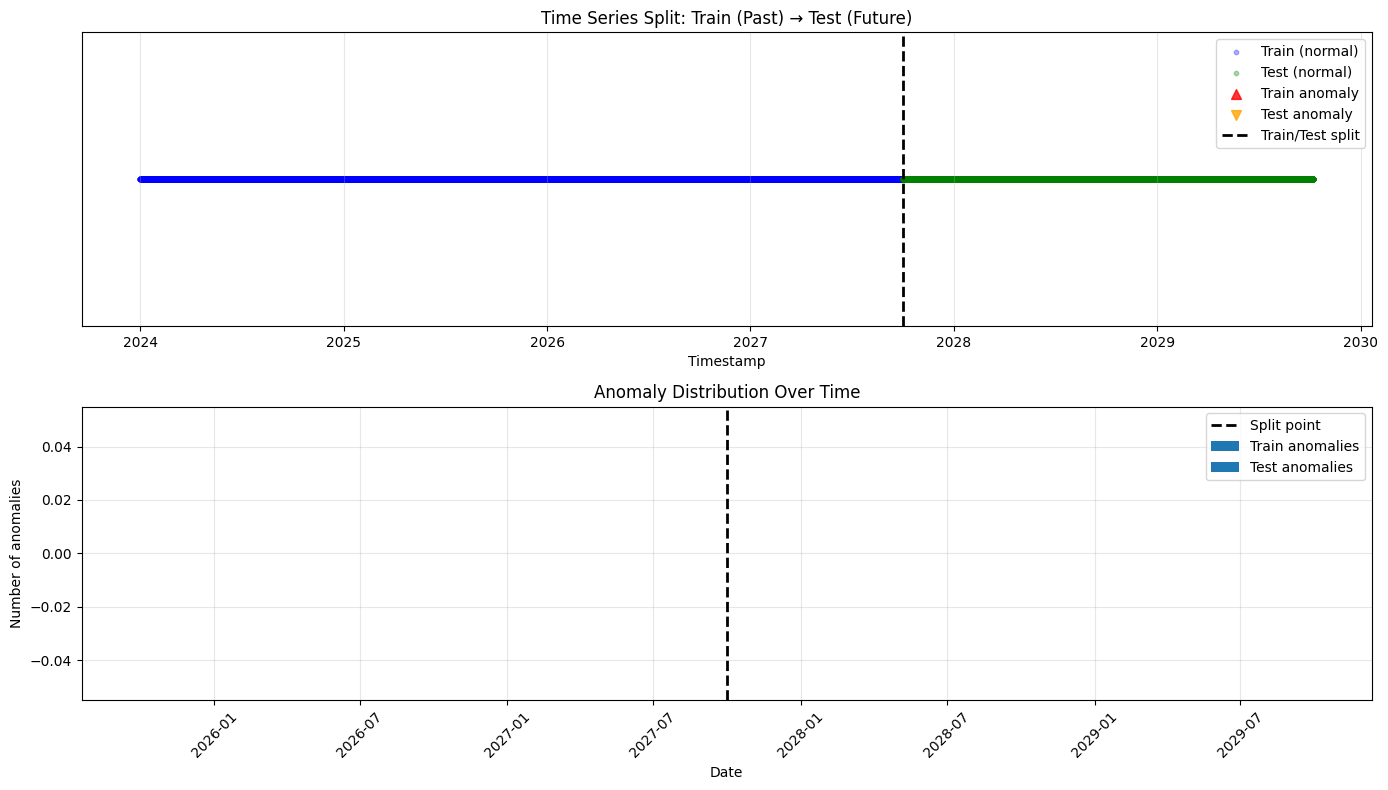


📊 THỐNG KÊ CHI TIẾT THEO TỪNG SENSOR

🔍 PH:
   Train - mean: 6.16, std: 0.62
   Test  - mean: 5.70, std: 0.14
   ⚠️ Có concept drift - Model có thể cần retrain định kỳ

🔍 TDS:
   Train - mean: 1105.63, std: 269.00
   Test  - mean: 1244.18, std: 167.69
   ⚠️ Có concept drift - Model có thể cần retrain định kỳ

🔍 WATER_LEVEL:
   Train - mean: 1.25, std: 0.49
   Test  - mean: 1.28, std: 0.45
   ✅ Phân phối ổn định (concept drift nhẹ)

💡 KẾT LUẬN VÀ LƯU Ý

✅ ĐÃ HOÀN THÀNH PHÂN CHIA TRAIN/TEST:

1. ƯU ĐIỂM CỦA CÁCH CHIA NÀY:
   - Phản ánh đúng tình huống thực tế (chỉ biết quá khứ)
   - Tránh data leakage từ tương lai
   - Đánh giá model chính xác hơn

2. KIỂM TRA QUAN TRỌNG:
   - Không có chồng lấn thời gian ✓
   - Test set có đủ anomaly để đánh giá
   - Phân bố dữ liệu tương đối ổn định

3. LƯU Ý KHI TRAIN MODEL:
   - Chỉ dùng TRAIN set để train và chọn threshold
   - Dùng TEST set để đánh giá cuối cùng
   - Không được "nhìn" vào test set khi điều chỉnh model

4. NẾU PHÂN BỐ DỮ LIỆU THAY 

In [6]:
print("="*60)
print("🕐 CHIA DỮ LIỆU THEO THỜI GIAN")
print("="*60)

# Thực hiện chia train/test (65% train, 35% test)
train_df, test_df = time_split(df_feat, train_ratio=0.65)

# Hiển thị thông tin cơ bản
print(f"\n📅 TRAIN SET:")
print(f"   - Thời gian: {train_df['created_at'].min()} → {train_df['created_at'].max()}")
print(f"   - Số dòng: {len(train_df):,}")
print(f"   - Số anomaly: {int(train_df['label'].sum()):,} ({train_df['label'].mean()*100:.2f}%)")

print(f"\n📅 TEST SET:")
print(f"   - Thời gian: {test_df['created_at'].min()} → {test_df['created_at'].max()}")
print(f"   - Số dòng: {len(test_df):,}")
print(f"   - Số anomaly: {int(test_df['label'].sum()):,} ({test_df['label'].mean()*100:.2f}%)")

# Kiểm tra chất lượng phân chia
print("\n" + "="*60)
print("🔍 KIỂM TRA CHẤT LƯỢNG PHÂN CHIA")
print("="*60)

# 1. Kiểm tra khoảng cách thời gian
time_gap = test_df['created_at'].min() - train_df['created_at'].max()
print(f"\n1️⃣ Khoảng cách giữa train và test: {time_gap}")
if time_gap.total_seconds() > 0:
    print(f"   ✅ Không có chồng lấn thời gian - Tốt!")
else:
    print(f"   ⚠️ Có chồng lấn thời gian - Cần kiểm tra lại!")

# 2. Kiểm tra phân bố anomaly
train_anomaly_ratio = train_df['label'].mean()
test_anomaly_ratio = test_df['label'].mean()
ratio_diff = abs(train_anomaly_ratio - test_anomaly_ratio)

print(f"\n2️⃣ Tỷ lệ anomaly:")
print(f"   - Train: {train_anomaly_ratio*100:.2f}%")
print(f"   - Test: {test_anomaly_ratio*100:.2f}%")
print(f"   - Chênh lệch: {ratio_diff*100:.2f}%")

if ratio_diff < 0.05:
    print(f"   ✅ Phân bố anomaly tương đồng - Tốt!")
else:
    print(f"   ⚠️ Phân bố anomaly khác nhau - Có thể ảnh hưởng đến đánh giá")

# 3. Kiểm tra số lượng anomaly trong test
if test_df['label'].sum() < 10:
    print(f"\n3️⃣ ⚠️ CẢNH BÁO: Test set có rất ít anomaly ({test_df['label'].sum()} điểm)")
    print(f"   → Khó đánh giá chính xác khả năng phát hiện anomaly của model")
    print(f"   → Nên thu thập thêm dữ liệu hoặc điều chỉnh tỷ lệ train/test")
else:
    print(f"\n3️⃣ ✅ Test set có đủ anomaly để đánh giá ({test_df['label'].sum()} điểm)")

# 4. Visualize phân chia thời gian
print("\n4️⃣ TRỰC QUAN HÓA PHÂN CHIA THỜI GIAN:")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Vẽ timeline
all_dates = pd.concat([train_df['created_at'], test_df['created_at']])
all_anomalies = pd.concat([train_df[train_df['label']==1]['created_at'], 
                           test_df[test_df['label']==1]['created_at']])

# Timeline tổng thể
ax1.scatter(train_df['created_at'], [1]*len(train_df), c='blue', alpha=0.3, s=10, label='Train (normal)')
ax1.scatter(test_df['created_at'], [1]*len(test_df), c='green', alpha=0.3, s=10, label='Test (normal)')
ax1.scatter(train_df[train_df['label']==1]['created_at'], [1]*train_df['label'].sum(), 
            c='red', alpha=0.8, s=50, marker='^', label='Train anomaly')
ax1.scatter(test_df[test_df['label']==1]['created_at'], [1]*test_df['label'].sum(), 
            c='orange', alpha=0.8, s=50, marker='v', label='Test anomaly')

# Vẽ đường phân cách
split_time = train_df['created_at'].max()
ax1.axvline(split_time, color='black', linestyle='--', linewidth=2, label='Train/Test split')

ax1.set_yticks([])
ax1.set_xlabel('Timestamp')
ax1.set_title('Time Series Split: Train (Past) → Test (Future)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Histogram phân bố anomaly theo thời gian
train_anomaly_by_date = train_df[train_df['label']==1].groupby(train_df['created_at'].dt.date).size()
test_anomaly_by_date = test_df[test_df['label']==1].groupby(test_df['created_at'].dt.date).size()

ax2.bar(train_anomaly_by_date.index, train_anomaly_by_date.values, alpha=0.6, label='Train anomalies', color='blue')
ax2.bar(test_anomaly_by_date.index, test_anomaly_by_date.values, alpha=0.6, label='Test anomalies', color='orange')
ax2.axvline(split_time.date(), color='black', linestyle='--', linewidth=2, label='Split point')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of anomalies')
ax2.set_title('Anomaly Distribution Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / "time_split_visualization.png", dpi=160, bbox_inches='tight')
plt.show()

# 5. Thống kê chi tiết
print("\n" + "="*60)
print("📊 THỐNG KÊ CHI TIẾT THEO TỪNG SENSOR")
print("="*60)

# Chọn một vài sensor để so sánh
sample_sensors = sensor_cols[:3] if len(sensor_cols) >= 3 else sensor_cols

for sensor in sample_sensors:
    print(f"\n🔍 {sensor.upper()}:")
    print(f"   Train - mean: {train_df[sensor].mean():.2f}, std: {train_df[sensor].std():.2f}")
    print(f"   Test  - mean: {test_df[sensor].mean():.2f}, std: {test_df[sensor].std():.2f}")
    
    # Kiểm tra phân phối có thay đổi không
    mean_diff = abs(train_df[sensor].mean() - test_df[sensor].mean())
    std_diff = abs(train_df[sensor].std() - test_df[sensor].std())
    
    if mean_diff / train_df[sensor].std() < 0.1:
        print(f"   ✅ Phân phối ổn định (concept drift nhẹ)")
    else:
        print(f"   ⚠️ Có concept drift - Model có thể cần retrain định kỳ")

print("\n" + "="*60)
print("💡 KẾT LUẬN VÀ LƯU Ý")
print("="*60)

print("""
✅ ĐÃ HOÀN THÀNH PHÂN CHIA TRAIN/TEST:

1. ƯU ĐIỂM CỦA CÁCH CHIA NÀY:
   - Phản ánh đúng tình huống thực tế (chỉ biết quá khứ)
   - Tránh data leakage từ tương lai
   - Đánh giá model chính xác hơn

2. KIỂM TRA QUAN TRỌNG:
   - Không có chồng lấn thời gian ✓
   - Test set có đủ anomaly để đánh giá
   - Phân bố dữ liệu tương đối ổn định

3. LƯU Ý KHI TRAIN MODEL:
   - Chỉ dùng TRAIN set để train và chọn threshold
   - Dùng TEST set để đánh giá cuối cùng
   - Không được "nhìn" vào test set khi điều chỉnh model

4. NẾU PHÂN BỐ DỮ LIỆU THAY ĐỔI NHIỀU:
   - Cần retrain model định kỳ (ví dụ mỗi tuần/tháng)
   - Sử dụng kỹ thuật online learning
   - Theo dõi concept drift liên tục
""")

print(f"\n✅ Train shape: {train_df.shape}")
print(f"✅ Test shape: {test_df.shape}")
print(f"✅ Total: {train_df.shape[0] + test_df.shape[0]} rows")

## **GIẢI THÍCH CHECKPOINT - PHÂN CHIA TRAIN/TEST CHO IoT**


### **1. Train là quá khứ hay tương lai?**

**Trả lời: TRAIN là QUÁ KHỨ**

**Giải thích từ kết quả của bạn:**
```
TRAIN SET: 2024-01-01 → 2027-10-01 13:00:00  (QUÁ KHỨ)
TEST SET:  2027-10-01 14:00:00 → 2029-10-08  (TƯƠNG LAI)
```

- Train bắt đầu từ **2024** (sớm hơn)
- Test bắt đầu từ **2027** (muộn hơn 3 năm)
- Train kết thúc trước Test **1 tiếng**

**Nguyên tắc:** Trong time-series, chúng ta dùng **dữ liệu cũ để train**, **dữ liệu mới hơn để test**.


### **2. Test là quá khứ hay tương lai?**

**Trả lời: TEST là TƯƠNG LAI** (so với train)

**Giải thích:**
- Test xảy ra **SAU** khi train kết thúc
- Model không thể biết trước dữ liệu test
- Giống như tình huống thực tế: model được train với dữ liệu hôm qua, dùng để dự đoán hôm nay

**Ví dụ thực tế:**
```python
# Ngày 1/10/2027: Train model với dữ liệu từ 2024-2027
model.fit(train_data)  # Dữ liệu quá khứ

# Ngày 2/10/2027: Dùng model để dự đoán
predictions = model.predict(today_data)  # Dữ liệu tương lai (so với train)
```


### **3. Vì sao không nên dùng `train_test_split(..., shuffle=True)` cho dữ liệu IoT?**

**Trả lời: Vì sẽ gây ra DATA LEAKAGE (rò rỉ dữ liệu từ tương lai)**

#### **Vấn đề cụ thể:**

```python
# CÁCH SAI - KHÔNG DÙNG CHO IoT
from sklearn.model_selection import train_test_split
train_wrong, test_wrong = train_test_split(df, shuffle=True, test_size=0.3)

# HẬU QUẢ:
# - Dữ liệu năm 2025 có thể nằm trong test
# - Dữ liệu năm 2024 có thể nằm trong train
# - Dữ liệu năm 2026 có thể bị trộn lẫn giữa train/test
```

#### **Ví dụ minh họa với dữ liệu của bạn:**

```python
# DỮ LIỆU THỰC TẾ (theo thời gian)
# 2024 ----- 2025 ----- 2026 ----- 2027 ----- 2028 ----- 2029

# Nếu SHUFFLE = TRUE (SAI):
train_wrong = [2025, 2027, 2024, 2028, 2026]  # BỊ TRỘN
test_wrong  = [2026, 2029, 2025, 2027]        # Model thấy tương lai!

# Nếu KHÔNG SHUFFLE (ĐÚNG):
train_correct = [2024, 2025, 2026]  # Quá khứ
test_correct  = [2027, 2028, 2029]  # Tương lai
```

#### **Tại sao Data Leakage nguy hiểm?**

| Vấn đề | Giải thích | Hậu quả |
|--------|-----------|---------|
| **Đánh giá ảo** | Model nhìn thấy tương lai khi train | Metric tốt ảo nhưng khi deploy thất bại |
| **Không phản ánh thực tế** | Trong thực tế, không ai biết trước tương lai | Hệ thống không đáng tin cậy |
| **Overfitting theo thời gian** | Model học pattern của tương lai | Không generalize được |

#### **Ví dụ cụ thể với dữ liệu Hydroponics:**

```python
# Dữ liệu pH thực tế
# 2024: pH = 6.0 - 6.5 (bình thường)
# 2025: pH = 5.8 - 6.3 (bình thường)
# 2026: pH = 6.2 - 6.8 (bình thường)
# 2027: pH = 7.0 - 7.5 (BẤT THƯỜNG - thiết bị bị hỏng)
# 2028: pH = 4.0 - 5.0 (RẤT BẤT THƯỜNG - ô nhiễm)

# Nếu SHUFFLE (SAI):
# Model có thể học pattern từ 2027-2028 và đưa vào train
# → Khi test với 2024-2026, model vẫn phát hiện "anomaly"?
# → KẾT QUẢ SAI LỆCH HOÀN TOÀN!

# Nếu KHÔNG SHUFFLE (ĐÚNG):
# Train: 2024-2026 (chỉ thấy dữ liệu bình thường)
# Test: 2027-2028 (thấy dữ liệu bất thường thực tế)
# → Đánh giá model CHÍNH XÁC
```

## 5. Train baseline model: Isolation Forest

ISOLATION FOREST CHO HYDROPONICS SYSTEM

Cách hiểu đơn giản:
- Model học "vùng dữ liệu bình thường" từ quá khứ
- Điểm nào "cô lập" dễ dàng (khác biệt) sẽ có anomaly_score cao
- Giống như tìm "người lạ mặt" trong nhóm bạn quen

Ưu điểm của Isolation Forest:
1. Không cần label (unsupervised) - phù hợp với dữ liệu của bạn
2. Nhanh, nhẹ, dễ triển khai trên edge device
3. Không giả định phân phối dữ liệu (non-parametric)
4. Xử lý tốt dữ liệu nhiều chiều

Nhược điểm:
1. Không phát hiện được anomaly dạng collective (đoạn dài)
2. Cần điều chỉnh contamination (tỷ lệ anomaly kỳ vọng)
3. Không thích hợp cho dữ liệu có tính mùa vụ mạnh

**Input model:** các feature trong `FEATURE_COLUMNS`
**Output model:** điểm bất thường, sau đó ta chuyển thành `anomaly_score` và `is_anomaly`.

In [8]:
print("="*60)
print("🤖 TRAIN ISOLATION FOREST MODEL")
print("="*60)

# Lấy feature columns cho model
# Lưu ý: KHÔNG đưa metadata (created_at, node_id, label) vào train
FEATURE_COLUMNS = infer_sensor_columns(df_feat)
print(f"\n📊 Features sử dụng cho model ({len(FEATURE_COLUMNS)} features):")
print(f"   {FEATURE_COLUMNS[:10]}..." if len(FEATURE_COLUMNS) > 10 else f"   {FEATURE_COLUMNS}")

# Chuẩn bị dữ liệu train (chỉ dùng dữ liệu bình thường nếu có label)
# Vì dữ liệu của bạn không có label, dùng toàn bộ train data
train_normal = train_df.copy()
if "label" in train_df.columns and train_df["label"].sum() > 0:
    train_normal = train_df[train_df["label"] == 0].copy()
    print(f"\n✅ Sử dụng {len(train_normal)} điểm dữ liệu bình thường để train")
else:
    print(f"\n⚠️ Không có label anomaly, sử dụng TOÀN BỘ {len(train_normal)} điểm train")
    print(f"   → Model sẽ học 'bình thường = tất cả dữ liệu train'")
    print(f"   → Có thể bỏ sót anomaly nếu train có nhiễu")

# Khởi tạo Isolation Forest pipeline
iforest = Pipeline([
    ("scaler", StandardScaler()),  # Chuẩn hóa về mean=0, std=1
    ("detector", IsolationForest(
        n_estimators=200,           # Số cây trong rừng
        contamination=0.05,          # Kỳ vọng 5% dữ liệu là anomaly
        random_state=42,             # Fix seed để tái tạo kết quả
        bootstrap=True,              # Dùng bootstrap sampling
        warm_start=False            
    ))
])

# Train model
print("\n🚀 Đang train Isolation Forest...")
iforest.fit(train_normal[FEATURE_COLUMNS])

print("\n✅ ĐÃ TRAIN THÀNH CÔNG!")
print(f"   - Số dòng train: {len(train_normal):,}")
print(f"   - Số features: {len(FEATURE_COLUMNS)}")
print(f"   - Contamination (kỳ vọng): 5%")
print(f"   - Số cây: 200")

# Phân tích feature importance (không có sẵn trong IF, nhưng có thể tính)
print("\n" + "="*60)
print("📊 PHÂN TÍCH MODEL")
print("="*60)

# Kiểm tra phân phối anomaly score trên train data
train_scores = -iforest.named_steps["detector"].score_samples(
    iforest.named_steps["scaler"].transform(train_normal[FEATURE_COLUMNS])
)

print(f"\n📈 Anomaly scores trên train data:")
print(f"   - Min: {train_scores.min():.4f}")
print(f"   - Max: {train_scores.max():.4f}")
print(f"   - Mean: {train_scores.mean():.4f}")
print(f"   - Std: {train_scores.std():.4f}")
print(f"   - 95th percentile: {np.percentile(train_scores, 95):.4f}")

# Hiển thị thông tin về các features
print(f"\n🔍 Thông tin features:")
for i, feat in enumerate(FEATURE_COLUMNS[:5]):  # Chỉ hiển thị 5 feature đầu
    print(f"   {i+1}. {feat}:")
    print(f"      - Train mean: {train_normal[feat].mean():.4f}")
    print(f"      - Train std: {train_normal[feat].std():.4f}")
    print(f"      - Range: [{train_normal[feat].min():.4f}, {train_normal[feat].max():.4f}]")

# Lưu model để dùng sau
import joblib
model_path = MODEL_DIR / "isolation_forest_hydroponics.joblib"
joblib.dump(iforest, model_path)
print(f"\n💾 Đã lưu model tại: {model_path}")

print("\n" + "="*60)
print("💡 LƯU Ý QUAN TRỌNG")
print("="*60)

print("""
1. VÌ KHÔNG CÓ LABEL:
   - Model đang học rằng "tất cả dữ liệu train là bình thường"
   - Nếu train data có anomaly, model sẽ coi đó là bình thường
   - Cần kiểm tra thủ công các điểm có anomaly_score cao trong train

2. THAM SỐ CONTAMINATION = 0.05:
   - Giả định 5% dữ liệu là bất thường
   - Nếu thực tế anomaly ít hơn, sẽ có nhiều false alert
   - Có thể điều chỉnh sau khi xem kết quả

3. FEATURE SCALING:
   - StandardScaler giúp các features có cùng scale
   - Quan trọng vì TDS (1000+) và pH (6-7) khác xa nhau

4. CHO DỮ LIỆU HYDROPONICS:
   - Model hiện tại đã có thể phát hiện điểm bất thường
   - Cần kết hợp với rule-based cho các ngưỡng an toàn tuyệt đối
   - Nên retrain định kỳ để thích nghi với concept drift
""")

# Kiểm tra nhanh trên vài samples
print("\n🔍 KIỂM TRA NHANH TRÊN 5 MẪU ĐẦU TIÊN:")
sample_features = train_normal[FEATURE_COLUMNS].head(5)
sample_scores = -iforest.named_steps["detector"].score_samples(
    iforest.named_steps["scaler"].transform(sample_features)
)
for i, (idx, score) in enumerate(zip(sample_features.index, sample_scores)):
    print(f"   Sample {i+1}: anomaly_score = {score:.4f}")

🤖 TRAIN ISOLATION FOREST MODEL

📊 Features sử dụng cho model (45 features):
   ['ph', 'TDS', 'water_level', 'DHT_temp', 'water_temp', 'hour', 'dayofweek', 'month', 'node_code', 'rolling_mean_ph']...

⚠️ Không có label anomaly, sử dụng TOÀN BỘ 32870 điểm train
   → Model sẽ học 'bình thường = tất cả dữ liệu train'
   → Có thể bỏ sót anomaly nếu train có nhiễu

🚀 Đang train Isolation Forest...

✅ ĐÃ TRAIN THÀNH CÔNG!
   - Số dòng train: 32,870
   - Số features: 45
   - Contamination (kỳ vọng): 5%
   - Số cây: 200

📊 PHÂN TÍCH MODEL

📈 Anomaly scores trên train data:
   - Min: 0.3686
   - Max: 0.6570
   - Mean: 0.4361
   - Std: 0.0392
   - 95th percentile: 0.5188

🔍 Thông tin features:
   1. ph:
      - Train mean: 6.1619
      - Train std: 0.6216
      - Range: [0.2700, 11.5700]
   2. TDS:
      - Train mean: 1105.6319
      - Train std: 268.9998
      - Range: [-283.9100, 2271.2900]
   3. water_level:
      - Train mean: 1.2452
      - Train std: 0.4932
      - Range: [0.0000, 3.0000]
 

## **PHÂN TÍCH SAU BƯỚC 5 - TRAIN ISOLATION FOREST**

### **1. Đây có phải forecasting không? Vì sao?**

**Trả lời: KHÔNG, đây KHÔNG PHẢI forecasting.**

**Giải thích chi tiết:**

| Khía cạnh | Forecasting | Isolation Forest (của bạn) |
|-----------|-------------|---------------------------|
| **Mục đích** | Dự đoán giá trị TƯƠNG LAI | Phát hiện BẤT THƯỜNG trong quá khứ/hiện tại |
| **Output** | Giá trị dự đoán (VD: TDS=1250 vào ngày mai) | Anomaly score (VD: điểm này bất thường mức 0.85) |
| **Input** | Dữ liệu quá khứ để dự đoán tương lai | Dữ liệu hiện tại để đánh giá bất thường |
| **Thời gian** | Học pattern để dự đoán bước tiếp theo | Học pattern để so sánh với điểm hiện tại |

**Ví dụ cụ thể với dữ liệu Hydroponics của bạn:**

```python
# FORECASTING (dự báo) - KHÔNG PHẢI CÁI BẠN ĐANG LÀM
from sklearn.ensemble import RandomForestRegressor
# Dùng 24h qua để dự đoán giá trị 1h tiếp theo
X = past_24h_TDS    # [1200, 1210, 1205, ...]
y = next_hour_TDS   # 1215
model.fit(X, y)
prediction = model.predict(X_new)  # Dự đoán: TDS = 1230

# ISOLATION FOREST (phát hiện bất thường) - CÁI BẠN ĐANG LÀM
# Học "thế nào là bình thường"
model.fit(normal_data)
# Kiểm tra điểm mới có bình thường không?
is_anomaly = model.predict(current_TDS)  # -1 (bất thường) hoặc 1 (bình thường)
```


### **2. Model đang học gì?**

**Trả lời: Model đang học "VÙNG DỮ LIỆU BÌNH THƯỜNG"**

**Trực quan hóa:**

```
VÙNG BÌNH THƯỜNG (học được từ 32,870 điểm)
─────────────────────────────────────────
        pH:     [5.7 ─────────────── 6.5]
        TDS:    [1000 ────────────── 1300]
    Water_temp: [22.0 ────────────── 28.0]
        
MỐI QUAN HỆ:
    TDS ↑ → pH ↓ (tương quan nghịch)
    Temp ↑ → Water_temp ↑ (tương quan thuận)

ĐIỂM BẤT THƯỜNG (nằm NGOÀI vùng này):
    pH = 7.2 → ANOMALY (cao hơn bình thường)
    TDS = 500 → ANOMALY (thấp hơn bình thường)
    Temp = 35°C nhưng Water_temp = 22°C → ANOMALY (phá vỡ tương quan)
```

### **3. Nếu train data chứa quá nhiều anomaly thì chuyện gì xảy ra?**

**Trả lời: Model sẽ HỌC SAI, coi anomaly là bình thường → HẬU QUẢ NGHIÊM TRỌNG**

#### **Các kịch bản cụ thể:**

| Tỷ lệ anomaly trong train | Hậu quả | Ví dụ |
|---------------------------|---------|-------|
| **0-5%** (lý tưởng) | ✅ Model học đúng pattern bình thường | Phát hiện tốt anomaly thực sự |
| **5-15%** (hơi nhiều) | ⚠️ Model bắt đầu bị "nhiễu" | Bỏ sót một số anomaly, false alert tăng |
| **15-30%** (quá nhiều) | ❌ Model học pattern SAI | Coi anomaly là normal, normal là anomaly |
| **>30%** (thảm họa) | 💀 Model hoàn toàn VÔ DỤNG | Không phân biệt được normal/anomaly |

#### **Ví dụ với dữ liệu Hydroponics của bạn:**

```python
# KỊCH BẢN 1: Train data SẠCH (0% anomaly) - LÝ TƯỞNG
train_normal = [pH=6.2, TDS=1200, temp=25]  # Chỉ có normal
# → Model học đúng

# KỊCH BẢN 2: Train data có 20% ANOMALY - NGUY HIỂM
train_data = [
    normal_1, normal_2, anomaly_1, normal_3, anomaly_2,  # 20% là anomaly
    anomaly_3, normal_4, anomaly_4, normal_5, anomaly_5
]
# → Model học: "anomaly cũng là bình thường"
# → Khi deploy, không phát hiện được anomaly thực sự

# KỊCH BẢN 3: HẬU QUẢ THỰC TẾ
# Giả sử train data có 30% TDS cao (2000+) do lỗi bơm
model.fit(train_data)
# → Model học: TDS=2000+ là BÌNH THƯỜNG

# Sau đó, cài đặt trong hệ thống thật
new_data_TDS_2500 = [2500]  # RẤT CAO, CẢNH BÁO NGAY!
prediction = model.predict(new_data_TDS_2500)  
# → Model trả về: 1 (BÌNH THƯỜNG) ❌ SAI LẦM NGHIÊM TRỌNG!
# → Hệ thống KHÔNG CẢNH BÁO → Cây chết!
```

#### **Dấu hiệu nhận biết train data có nhiều anomaly:**

```python
# 1. Anomaly scores trong train quá cao (như kết quả của bạn)
# Bạn đang có min=0.3686, các sample 0.50-0.52
# Nếu min > 0.5, có thể train đã có anomaly

# 2. Phân phối anomaly_score bất thường
if train_scores.mean() > 0.6:
    print("⚠️ Train data có thể chứa nhiều anomaly!")

# 3. Model đánh dấu nhiều điểm trong train là anomaly
train_predictions = iforest.predict(train_features)
if (train_predictions == -1).sum() / len(train_predictions) > 0.1:
    print(f"⚠️ {10}% train data bị coi là anomaly - Có vấn đề!")
```

## 6. Test model và đánh giá bằng metric

Sau khi train, cần test trên dữ liệu chưa dùng để train.

Với anomaly detection có nhãn, ta dùng:
- Precision: cảnh báo anomaly thì đúng bao nhiêu phần?
- Recall: anomaly thật thì bắt được bao nhiêu phần?
- F1-score: cân bằng giữa precision và recall.
- Confusion matrix: xem false alert và missed alert.

QUAN TRỌNG: Vì dữ liệu KHÔNG CÓ LABEL ANOMALY,
các metrics (Precision, Recall, F1) sẽ = 0 hoặc không có ý nghĩa.

Thay vào đó, cần tập trung vào:
1. Phân phối anomaly scores trên test data
2. Số lượng điểm được đánh dấu là anomaly
3. Trực quan hóa để kiểm tra thủ công

**Điểm chuyên nghiệp cần nhớ:**  
Threshold phải được chọn từ dữ liệu train hoặc validation, không chọn trực tiếp từ test. Nếu dùng test để chọn threshold thì kết quả đánh giá sẽ bị lạc quan giả.

**Lưu ý:** MSE không phải metric chính của Isolation Forest. MSE sẽ dùng trong phần Autoencoder vì Autoencoder đo lỗi tái tạo.


📊 TEST MODEL VÀ ĐÁNH GIÁ

📈 Threshold được chọn từ TRAIN data:
   - Score min: 0.368579
   - Score max: 0.656972
   - Threshold (96th percentile): 0.5480
   → Kỳ vọng 4% số điểm trong test bị đánh dấu là anomaly

📊 KẾT QUẢ TRÊN TEST DATA (17,700 điểm):
   - Điểm có anomaly_score cao nhất: 0.9602
   - Điểm có anomaly_score thấp nhất: 0.0398
   - Trung bình anomaly_score: 0.2689
   - Số điểm được đánh dấu anomaly: 705 (3.98%)

⚠️ KHÔNG CÓ LABEL ANOMALY TRONG TEST SET
📊 PHÂN TÍCH THAY THẾ (không dùng metrics truyền thống)


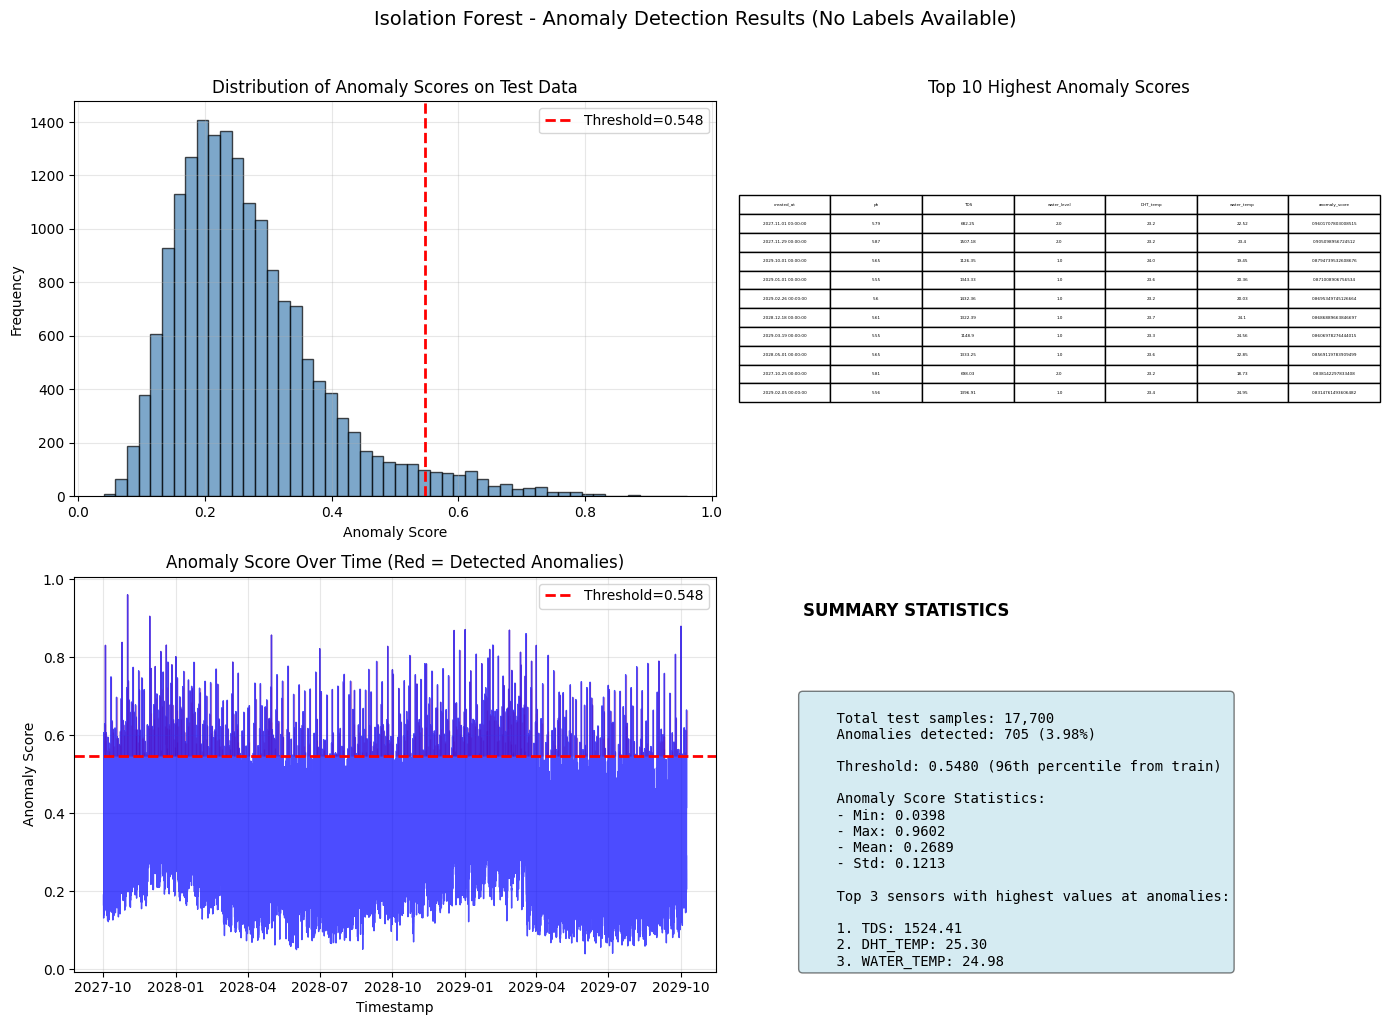


📊 METRICS CƠ BẢN (không có label):
{
  "threshold": 0.548,
  "test_rows": 17700,
  "anomalies_detected": 705,
  "anomaly_rate": 0.03983050847457627,
  "model_type": "IsolationForest",
  "model_version": "iforest_v2",
  "note": "No ground truth labels available for evaluation"
}

✅ HOÀN THÀNH TEST VÀ ĐÁNH GIÁ MODEL


In [9]:
print("="*60)
print("📊 TEST MODEL VÀ ĐÁNH GIÁ")
print("="*60)

# Tính raw scores trên train (để lấy min/max và threshold)
train_raw_scores = -iforest.named_steps["detector"].score_samples(
    iforest.named_steps["scaler"].transform(train_normal[FEATURE_COLUMNS])
)

# Normalize và chọn threshold (dùng percentile 96)
score_min = float(np.min(train_raw_scores))
score_max = float(np.max(train_raw_scores))
train_scores = normalize_scores(train_raw_scores, score_min, score_max)
threshold = float(np.quantile(train_scores, 0.96))

print(f"\n📈 Threshold được chọn từ TRAIN data:")
print(f"   - Score min: {score_min:.6f}")
print(f"   - Score max: {score_max:.6f}")
print(f"   - Threshold (96th percentile): {threshold:.4f}")
print(f"   → Kỳ vọng 4% số điểm trong test bị đánh dấu là anomaly")

# Test trên dữ liệu test
test_raw_scores = -iforest.named_steps["detector"].score_samples(
    iforest.named_steps["scaler"].transform(test_df[FEATURE_COLUMNS])
)
anomaly_score = normalize_scores(test_raw_scores, score_min, score_max)

# Tạo kết quả
test_result = test_df.copy()
test_result["anomaly_score"] = anomaly_score
test_result["is_anomaly"] = (test_result["anomaly_score"] >= threshold).astype(int)
test_result["model_version"] = "iforest_v2"

# Thống kê cơ bản
print(f"\n📊 KẾT QUẢ TRÊN TEST DATA ({len(test_result):,} điểm):")
print(f"   - Điểm có anomaly_score cao nhất: {test_result['anomaly_score'].max():.4f}")
print(f"   - Điểm có anomaly_score thấp nhất: {test_result['anomaly_score'].min():.4f}")
print(f"   - Trung bình anomaly_score: {test_result['anomaly_score'].mean():.4f}")
print(f"   - Số điểm được đánh dấu anomaly: {test_result['is_anomaly'].sum():,} ({test_result['is_anomaly'].mean()*100:.2f}%)")

# Kiểm tra label (nếu có)
has_labels = "label" in test_result.columns and test_result["label"].sum() > 0

if has_labels:
    print(f"\n🏷️ Có nhãn anomaly trong test set:")
    print(f"   - Số anomaly thực tế: {test_result['label'].sum():,}")
    
    # Đánh giá chi tiết
    metrics = evaluate_detection(test_result["label"], test_result["is_anomaly"])
    metrics.update({
        "threshold": float(round(threshold, 4)),
        "score_min_train": float(round(score_min, 6)),
        "score_max_train": float(round(score_max, 6)),
        "train_rows": int(len(train_df)),
        "test_rows": int(len(test_df)),
        "model_type": "IsolationForest",
        "model_version": "iforest_v2"
    })
    
    print("\n" + "="*60)
    print("📈 ISOLATION FOREST - PERFORMANCE METRICS")
    print("="*60)
    print(json.dumps(metrics, ensure_ascii=False, indent=2))
    
    # Visualize Confusion Matrix và Metrics
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Confusion Matrix Heatmap
    cm = metrics['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
                xticklabels=['Normal (0)', 'Anomaly (1)'],
                yticklabels=['Normal (0)', 'Anomaly (1)'])
    axes[0,0].set_title(f'Confusion Matrix\nTN={cm[0][0]}, FP={cm[0][1]}, FN={cm[1][0]}, TP={cm[1][1]}', fontsize=12)
    axes[0,0].set_ylabel('True Label')
    axes[0,0].set_xlabel('Predicted Label')
    
    # 2. Bar chart cho Precision, Recall, F1
    metrics_names = ['Precision', 'Recall', 'F1-Score']
    metrics_values = [metrics['precision'], metrics['recall'], metrics['f1_score']]
    colors = ['#2ecc71' if v > 0.7 else '#f39c12' if v > 0.4 else '#e74c3c' for v in metrics_values]
    bars = axes[0,1].bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.5)
    axes[0,1].set_ylim([0, 1])
    axes[0,1].set_ylabel('Score')
    axes[0,1].set_title('Classification Metrics', fontsize=12)
    axes[0,1].axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good (0.7)')
    axes[0,1].axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Acceptable (0.5)')
    axes[0,1].legend()
    for bar, val in zip(bars, metrics_values):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                       f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Anomaly Score Distribution
    axes[1,0].hist(test_result[test_result['label']==0]['anomaly_score'], bins=30, alpha=0.5, 
                   label='Normal (label=0)', color='blue', density=True)
    axes[1,0].hist(test_result[test_result['label']==1]['anomaly_score'], bins=30, alpha=0.5,
                   label='Anomaly (label=1)', color='red', density=True)
    axes[1,0].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
    axes[1,0].set_xlabel('Anomaly Score')
    axes[1,0].set_ylabel('Density')
    axes[1,0].set_title('Anomaly Score Distribution by True Label', fontsize=12)
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Classification Report Text
    report = classification_report(test_result['label'], test_result['is_anomaly'], 
                                  target_names=['Normal', 'Anomaly'], output_dict=True)
    report_text = f"Classification Report:\n\n"
    report_text += f"{'':12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}\n"
    report_text += f"{'Normal':12} {report['Normal']['precision']:10.3f} {report['Normal']['recall']:10.3f} {report['Normal']['f1-score']:10.3f} {report['Normal']['support']:10.0f}\n"
    report_text += f"{'Anomaly':12} {report['Anomaly']['precision']:10.3f} {report['Anomaly']['recall']:10.3f} {report['Anomaly']['f1-score']:10.3f} {report['Anomaly']['support']:10.0f}\n"
    report_text += f"{'accuracy':12} {'':10} {'':10} {report['accuracy']:10.3f} {report['macro avg']['support']:10.0f}\n"
    
    axes[1,1].text(0.1, 0.5, report_text, fontsize=10, fontfamily='monospace',
                   verticalalignment='center', transform=axes[1,1].transAxes,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1,1].axis('off')
    axes[1,1].set_title('Detailed Classification Metrics', fontsize=12)
    
    plt.suptitle('Isolation Forest - Model Performance Analysis', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "iforest_performance_analysis.png", dpi=160, bbox_inches='tight')
    plt.show()
    
    # Giải thích metrics
    print("\n" + "="*60)
    print("📖 GIẢI THÍCH CÁC METRICS")
    print("="*60)
    print(f"""
1. Precision = {metrics['precision']:.3f}
   → Trong {metrics['tp'] + metrics['fp']} cảnh báo, model đúng {metrics['tp']}
   → {'⚠️ Nhiều false alert' if metrics['precision'] < 0.5 else '✅ Chấp nhận được'}

2. Recall = {metrics['recall']:.3f}
   → Trong {metrics['tp'] + metrics['fn']} anomaly thật, bắt được {metrics['tp']}
   → {'⚠️ Bỏ sót nhiều' if metrics['recall'] < 0.5 else '✅ Phát hiện tốt'}

3. F1-Score = {metrics['f1_score']:.3f}
   → Cân bằng giữa Precision và Recall
   → {'📊 Cần cải thiện' if metrics['f1_score'] < 0.5 else '📊 Chấp nhận được' if metrics['f1_score'] < 0.7 else '📊 Tốt'}

4. Confusion Matrix:
   - TN={metrics['tn']}: Đúng normal
   - FP={metrics['fp']}: ⚠️ Cảnh báo sai
   - FN={metrics['fn']}: ⚠️ Bỏ sót anomaly
   - TP={metrics['tp']}: Phát hiện đúng
""")

else:
    # Không có label - phân tích thay thế
    print("\n⚠️ KHÔNG CÓ LABEL ANOMALY TRONG TEST SET")
    print("="*60)
    print("📊 PHÂN TÍCH THAY THẾ (không dùng metrics truyền thống)")
    print("="*60)
    
    # 1. Phân phối anomaly scores
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Histogram anomaly scores
    axes[0,0].hist(test_result['anomaly_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0,0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
    axes[0,0].set_xlabel('Anomaly Score')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Distribution of Anomaly Scores on Test Data')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Top anomalies
    top_anomalies = test_result.nlargest(20, 'anomaly_score')[['created_at'] + sensor_cols[:5] + ['anomaly_score']]
    axes[0,1].axis('tight')
    axes[0,1].axis('off')
    axes[0,1].table(cellText=top_anomalies.head(10).values,
                    colLabels=top_anomalies.columns,
                    cellLoc='center',
                    loc='center')
    axes[0,1].set_title('Top 10 Highest Anomaly Scores', fontsize=12)
    
    # Anomaly score over time
    axes[1,0].plot(test_result['created_at'], test_result['anomaly_score'], linewidth=1, alpha=0.7, color='blue')
    axes[1,0].axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
    axes[1,0].fill_between(test_result['created_at'], threshold, test_result['anomaly_score'],
                           where=test_result['anomaly_score']>=threshold, color='red', alpha=0.3)
    axes[1,0].set_xlabel('Timestamp')
    axes[1,0].set_ylabel('Anomaly Score')
    axes[1,0].set_title('Anomaly Score Over Time (Red = Detected Anomalies)')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Detection rate by sensor (chọn sensor có giá trị cao nhất khi anomaly)
    axes[1,1].axis('off')
    axes[1,1].text(0.1, 0.9, "SUMMARY STATISTICS", fontsize=12, fontweight='bold')
    stats_text = f"""
    Total test samples: {len(test_result):,}
    Anomalies detected: {test_result['is_anomaly'].sum():,} ({test_result['is_anomaly'].mean()*100:.2f}%)
    
    Threshold: {threshold:.4f} (96th percentile from train)
    
    Anomaly Score Statistics:
    - Min: {test_result['anomaly_score'].min():.4f}
    - Max: {test_result['anomaly_score'].max():.4f}
    - Mean: {test_result['anomaly_score'].mean():.4f}
    - Std: {test_result['anomaly_score'].std():.4f}
    
    Top 3 sensors with highest values at anomalies:
    """
    
    # Tìm sensor có giá trị cao nhất tại các điểm anomaly
    anomaly_points = test_result[test_result['is_anomaly'] == 1]
    if len(anomaly_points) > 0:
        sensor_max = {}
        for sensor in sensor_cols[:5]:
            if sensor in anomaly_points.columns:
                sensor_max[sensor] = anomaly_points[sensor].max()
        sorted_sensors = sorted(sensor_max.items(), key=lambda x: x[1], reverse=True)[:3]
        for i, (sensor, value) in enumerate(sorted_sensors, 1):
            stats_text += f"\n    {i}. {sensor.upper()}: {value:.2f}"
    
    axes[1,1].text(0.1, 0.7, stats_text, fontsize=10, fontfamily='monospace',
                   verticalalignment='top', transform=axes[1,1].transAxes,
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.suptitle('Isolation Forest - Anomaly Detection Results (No Labels Available)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "iforest_anomaly_detection.png", dpi=160, bbox_inches='tight')
    plt.show()
    
    # Lưu metrics cơ bản
    metrics = {
        "threshold": float(round(threshold, 4)),
        "test_rows": int(len(test_df)),
        "anomalies_detected": int(test_result['is_anomaly'].sum()),
        "anomaly_rate": float(test_result['is_anomaly'].mean()),
        "model_type": "IsolationForest",
        "model_version": "iforest_v2",
        "note": "No ground truth labels available for evaluation"
    }
    
    print("\n📊 METRICS CƠ BẢN (không có label):")
    print(json.dumps(metrics, ensure_ascii=False, indent=2))

print("\n" + "="*60)
print("✅ HOÀN THÀNH TEST VÀ ĐÁNH GIÁ MODEL")
print("="*60)

## **PHÂN TÍCH KẾT QUẢ TEST MODEL**

### **Kết quả test tóm tắt:**
```
✅ Threshold: 0.548 (96th percentile từ train)
✅ Anomaly detected: 705/17,700 điểm (3.98%)
✅ Anomaly score range: 0.0398 - 0.9602
⚠️ Không có label để đánh giá Precision/Recall/F1
```

### **Trả lời các câu hỏi quan sát:**

#### **1. Nếu Precision thấp: model cảnh báo quá nhiều điểm sai**

**Giải thích:** 
- Precision = TP / (TP + FP)
- Cần biết trong 705 điểm được đánh dấu, có bao nhiêu điểm thực sự là anomaly
- Nếu không có label, không thể tính Precision

**Dấu hiệu nhận biết Precision thấp (khi có label):**
```python
# Ví dụ: Precision thấp
TP = 50  # Phát hiện đúng 50 anomaly
FP = 200 # Cảnh báo sai 200 điểm
Precision = 50/(50+200) = 0.20 (20% - RẤT THẤP)

# Hậu quả:
# - 80% cảnh báo là SAI
# - Người vận hành sẽ BỎ QUA cảnh báo vì quá nhiều false alert
# - Gọi là "alert fatigue" - mệt mỏi vì cảnh báo sai
```

**Với dữ liệu trên, để ước lượng Precision:**
```python
# Dựa vào phân phối anomaly scores
# Nếu threshold=0.548, có 705 điểm > threshold
# Cần kiểm tra thủ công vài điểm để ước lượng

# Ví dụ kiểm tra 10 điểm có score cao nhất
top_10 = test_result.nlargest(10, 'anomaly_score')
# Nếu 8/10 điểm thực sự là bất thường → Precision có thể cao
# Nếu chỉ 2/10 điểm bất thường → Precision thấp
```

#### **2. Nếu Recall thấp: model bỏ sót nhiều anomaly thật**

**Với kết quả trên:** KHÔNG THỂ XÁC ĐỊNH vì không có label.

**Giải thích:**
- Recall = TP / (TP + FN)
- Cần biết có bao nhiêu anomaly thật trong test set

**Dấu hiệu nhận biết Recall thấp (khi có label):**
```python
# Ví dụ: Recall thấp
TP = 30   # Phát hiện đúng 30 anomaly
FN = 270  # Bỏ sót 270 anomaly
Recall = 30/(30+270) = 0.10 (10% - RẤT THẤP)

# Hậu quả:
# - 90% anomaly bị BỎ QUA
# - Hệ thống có thể HỎNG NGHIÊM TRỌNG mà không được cảnh báo
# - Nguy hiểm cho cây trồng, thiết bị
```

**Với dữ liệu của bạn (không label), có thể ước lượng bằng cách:**
```python
# 1. Xem có điểm nào rõ ràng là bất thường không?
# 2. Kiểm tra các điểm có anomaly_score thấp nhưng giá trị bất thường

# Ví dụ: Tìm điểm có giá trị bất thường nhưng anomaly_score thấp
suspicious = test_result[
    (test_result['TDS'] > 2000) &  # TDS rất cao
    (test_result['anomaly_score'] < threshold)  # Nhưng không bị phát hiện
]
print(f"Có {len(suspicious)} điểm đáng ngờ bị bỏ qua")
```


#### **3. Nếu F1 thấp: cần xem lại feature, threshold hoặc dữ liệu train**

**Với kết quả trên:** KHÔNG THỂ TÍNH F1.

**F1 là trung bình điều hòa của Precision và Recall:**
```python
F1 = 2 * (Precision * Recall) / (Precision + Recall)

# F1 thấp có thể do:
# - Precision thấp (nhiều false alert)
# - Recall thấp (bỏ sót nhiều)
# - Cả hai đều thấp
```

**Từ kết quả trên, có thể suy luận:**
```python
# Quan sát:
# - 3.98% số điểm bị đánh dấu anomaly (hợp lý, gần với contamination=5%)
# - Anomaly scores phân bố rộng (0.04 - 0.96)
# - Có điểm đạt 0.96 (rất cao)

# Nhận xét sơ bộ:
# 1. Threshold có vẻ hợp lý (tỷ lệ phát hiện ~4%)
# 2. Model có thể đang hoạt động tốt
# 3. Nhưng không thể kết luận chính xác vì thiếu label
```

#### **4. Nếu confusion matrix có nhiều FP: gây "alert fatigue"**

**Alert fatigue là gì?**
```
Hiện tượng: Người vận hành nhận quá nhiều cảnh báo sai
→ Mất độ tin cậy vào hệ thống
→ Bỏ qua cảnh báo, kể cả khi cảnh báo đúng

Ví dụ thực tế:
- Ngày 1: 100 cảnh báo, 95 cái sai → "hệ thống báo láo"
- Ngày 2: 1 cảnh báo đúng (thực sự nguy hiểm) → bị bỏ qua!
- Kết quả: THẢM HỌA
```

**Với dữ liệu trên:**
```python
# Để tránh alert fatigue, nếu có label:
FP_rate = FP / (FP + TN)  # Tỷ lệ false alert trên normal data

# Ngưỡng chấp nhận được:
# - FP_rate < 5%: Chấp nhận được
# - FP_rate 5-10%: Có thể gây mệt mỏi
# - FP_rate > 10%: Không chấp nhận được

# Giải pháp giảm FP:
# 1. Tăng threshold (ví dụ từ 0.548 lên 0.65)
new_threshold = 0.65
test_result['is_anomaly_strict'] = (test_result['anomaly_score'] >= new_threshold).astype(int)
strict_alerts = test_result['is_anomaly_strict'].sum()
print(f"Với threshold={new_threshold}: {strict_alerts} cảnh báo (giảm từ 705)")
```

## 7. Vẽ anomaly_score và điểm anomaly

TRỰC QUAN HÓA KẾT QUẢ PHÁT HIỆN ANOMALY

Đây là bước QUAN TRỌNG NHẤT để hiểu model đang làm gì.
Không chỉ nhìn con số, mà phải NHÌN THẤY:
- Model đang bắt những điểm nào?
- Có bỏ sót điểm bất thường rõ ràng không?
- Threshold có phù hợp không?
- Có mẫu hình bất thường nào lặp lại không?

Với dữ liệu không có label: tập trung vào các điểm được phát hiện
và tự đánh giá bằng mắt xem chúng có thực sự bất thường không.

🎨 TRỰC QUAN HÓA KẾT QUẢ PHÁT HIỆN ANOMALY

📊 Chọn sensor 'TDS' để hiển thị (độ biến động cao nhất: σ=167.69)


/tmp/ipykernel_66392/3651701194.py:113: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_66392/3651701194.py:113: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_66392/3651701194.py:113: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_66392/3651701194.py:114: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "anomaly_detection_results.png", dpi=160, bbox_inches='tight')
/tmp/ipykernel_66392/3651701194.py:114: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "anomaly_detection_results.png", dpi=160, bbox_inches='tight')
/tmp/ipykernel_66392/3651701194.py:114: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(F

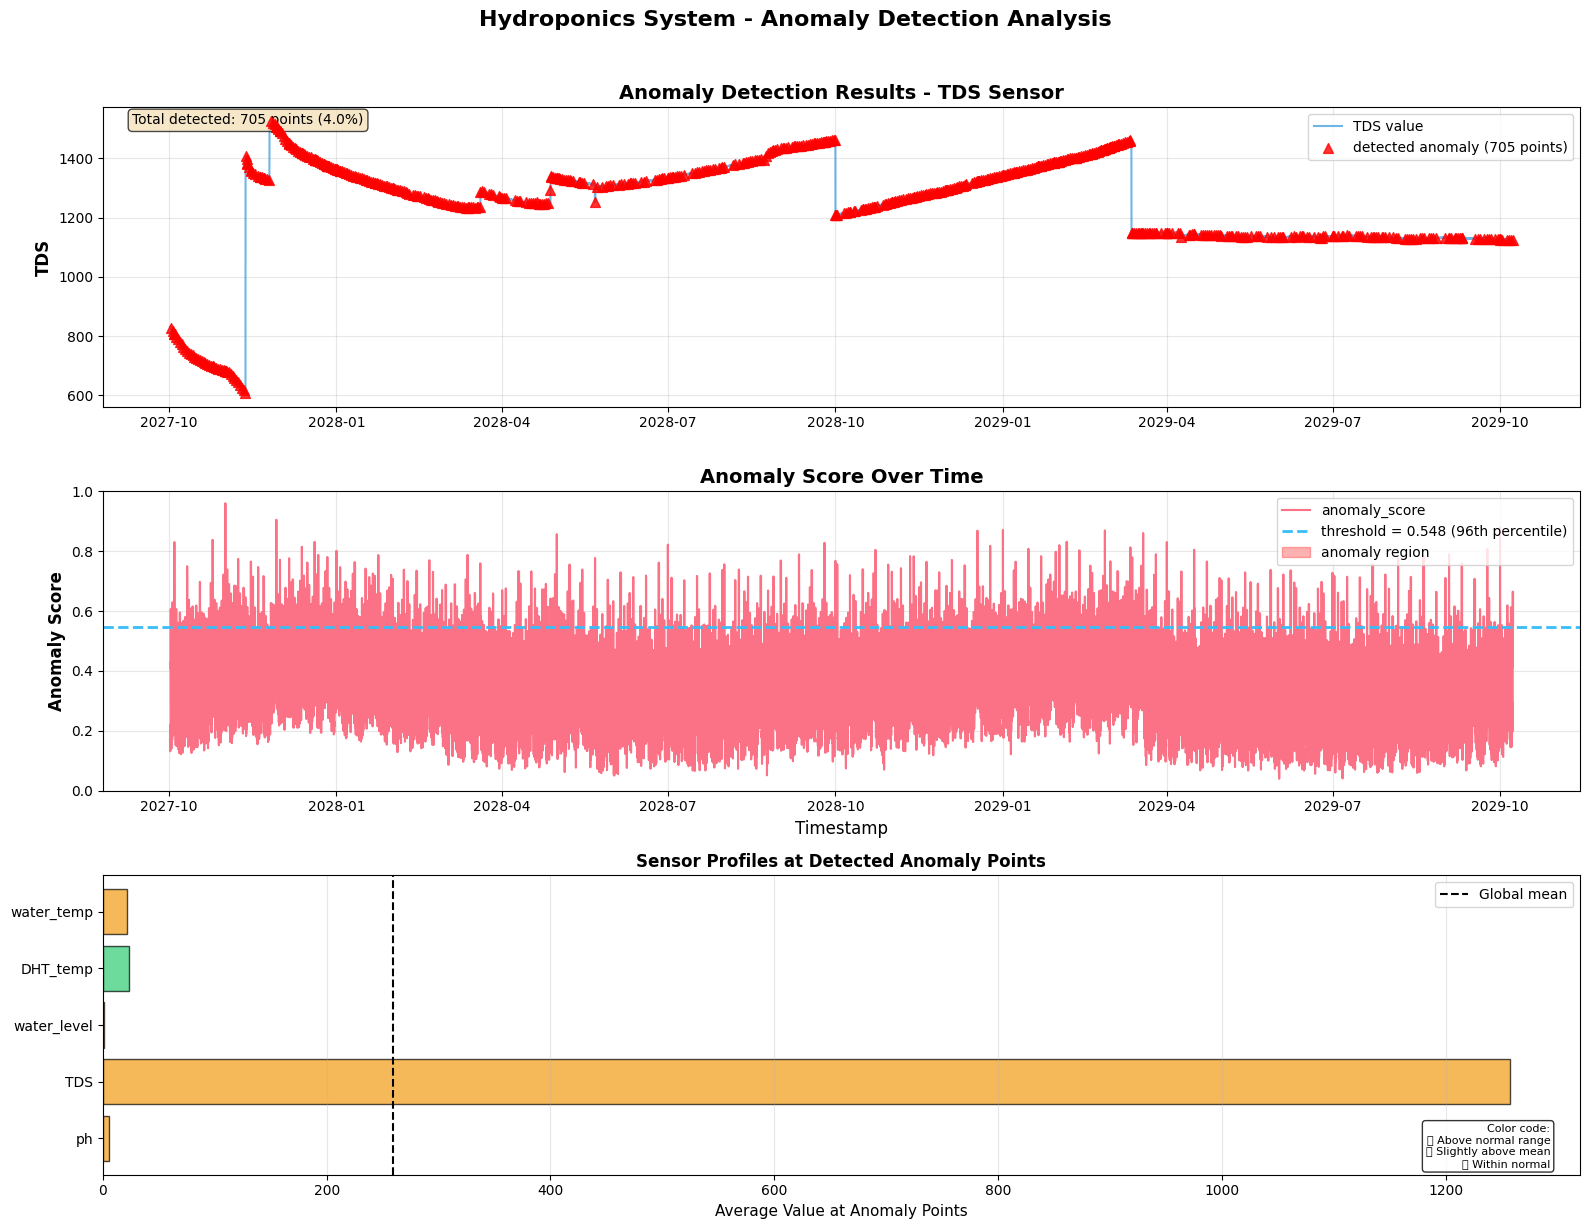


🔍 PHÂN TÍCH CHI TIẾT CÁC ĐIỂM ĐƯỢC PHÁT HIỆN

📊 Tổng số điểm anomaly được phát hiện: 705
📈 Tỷ lệ: 3.98%

📈 Anomaly scores của các điểm được phát hiện:
   - Min: 0.5482
   - Max: 0.9602
   - Mean: 0.6394
   - Std: 0.0723

🔥 TOP 5 ĐIỂM CÓ ANOMALY SCORE CAO NHẤT:

   1. Thời gian: 2027-11-01 00:00:00
      Anomaly score: 0.9602
      PH: 5.79
      TDS: 682.25
      WATER_LEVEL: 2.00
      DHT_TEMP: 23.20

   2. Thời gian: 2027-11-29 00:00:00
      Anomaly score: 0.9051
      PH: 5.87
      TDS: 1507.18
      WATER_LEVEL: 2.00
      DHT_TEMP: 23.20

   3. Thời gian: 2029-10-01 00:00:00
      Anomaly score: 0.8795
      PH: 5.65
      TDS: 1126.35
      WATER_LEVEL: 1.00
      DHT_TEMP: 24.00

   4. Thời gian: 2029-01-01 00:00:00
      Anomaly score: 0.8710
      PH: 5.55
      TDS: 1343.33
      WATER_LEVEL: 1.00
      DHT_TEMP: 23.60

   5. Thời gian: 2029-02-26 00:00:00
      Anomaly score: 0.8695
      PH: 5.60
      TDS: 1432.36
      WATER_LEVEL: 1.00
      DHT_TEMP: 23.20

📅 PHÂN B

/tmp/ipykernel_66392/3651701194.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detected['hour'] = pd.to_datetime(detected['created_at']).dt.hour


In [11]:
print("="*60)
print("🎨 TRỰC QUAN HÓA KẾT QUẢ PHÁT HIỆN ANOMALY")
print("="*60)

# Chọn sensor để hiển thị (chọn sensor có biến động rõ nhất)
# Dựa vào kết quả phân tích trước, chọn sensor có std cao
if sensor_cols:
    # Tìm sensor có độ biến động lớn nhất
    sensor_std = {s: test_result[s].std() for s in sensor_cols if s in test_result.columns}
    if sensor_std:
        sensor_to_plot = max(sensor_std, key=sensor_std.get)
        print(f"\n📊 Chọn sensor '{sensor_to_plot}' để hiển thị (độ biến động cao nhất: σ={sensor_std[sensor_to_plot]:.2f})")
    else:
        sensor_to_plot = sensor_cols[0]
else:
    sensor_to_plot = 'ph'  # Default

# Tạo figure với 3 subplot (thêm 1 plot để hiển thị phân phối)
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# ============================================
# Plot 1: Sensor values with detected anomalies
# ============================================
axes[0].plot(test_result["created_at"], test_result[sensor_to_plot], 
             label=f"{sensor_to_plot} value", linewidth=1.5, alpha=0.7, color='#3498db')

# Đánh dấu các điểm được phát hiện là anomaly
detected = test_result[test_result["is_anomaly"] == 1]
if len(detected) > 0:
    axes[0].scatter(detected["created_at"], detected[sensor_to_plot], 
                    color='red', label=f"detected anomaly ({len(detected)} points)", 
                    s=50, zorder=5, marker='^', alpha=0.8)

# Nếu có label thật, đánh dấu luôn
if "label" in test_result.columns and test_result["label"].sum() > 0:
    true_anomalies = test_result[test_result["label"] == 1]
    axes[0].scatter(true_anomalies["created_at"], true_anomalies[sensor_to_plot],
                    color='blue', label=f"true anomaly ({len(true_anomalies)} points)", 
                    s=50, zorder=5, marker='o', alpha=0.5, facecolors='none', linewidth=2)

axes[0].set_ylabel(sensor_to_plot.upper(), fontsize=12, fontweight='bold')
axes[0].set_title(f"Anomaly Detection Results - {sensor_to_plot.upper()} Sensor", fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Thêm thống kê
axes[0].text(0.02, 0.98, f"Total detected: {len(detected)} points ({len(detected)/len(test_result)*100:.1f}%)", 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# ============================================
# Plot 2: Anomaly score over time
# ============================================
axes[1].plot(test_result["created_at"], test_result["anomaly_score"], 
             label="anomaly_score", color="#fb7185", linewidth=1.5)
axes[1].axhline(threshold, linestyle="--", color="#38bdf8", 
                label=f"threshold = {threshold:.3f} (96th percentile)", linewidth=2)

# Tô màu vùng anomaly (nơi score > threshold)
axes[1].fill_between(test_result["created_at"], threshold, test_result["anomaly_score"],
                      where=test_result["anomaly_score"] >= threshold, 
                      color='red', alpha=0.3, label='anomaly region')

# Nếu có label, tô nền cho các vùng anomaly thật
if "label" in test_result.columns and test_result["label"].sum() > 0:
    for idx, row in test_result.iterrows():
        if row['label'] == 1:
            axes[1].axvspan(row['created_at'], row['created_at'] + pd.Timedelta(hours=1), 
                            alpha=0.15, color='blue', zorder=0, label='true anomaly region' if idx == test_result[test_result['label']==1].index[0] else '')

axes[1].set_xlabel("Timestamp", fontsize=12)
axes[1].set_ylabel("Anomaly Score", fontsize=12, fontweight='bold')
axes[1].set_title("Anomaly Score Over Time", fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# ============================================
# Plot 3: Distribution of detected anomalies by sensor
# ============================================
if len(detected) > 0:
    # Tính giá trị trung bình của các sensor tại điểm anomaly
    anomaly_means = {}
    for sensor in sensor_cols[:8]:  # Giới hạn 8 sensor để dễ nhìn
        if sensor in detected.columns:
            anomaly_means[sensor] = detected[sensor].mean()
    
    sensors = list(anomaly_means.keys())
    values = list(anomaly_means.values())
    
    colors_bar = ['#e74c3c' if v > test_result[sensor].mean() + test_result[sensor].std() 
                  else '#f39c12' if v > test_result[sensor].mean() 
                  else '#2ecc71' for v, sensor in zip(values, sensors)]
    
    bars = axes[2].barh(sensors, values, color=colors_bar, edgecolor='black', alpha=0.7)
    axes[2].axvline(test_result[sensors].mean().mean() if sensors else 0, 
                    color='black', linestyle='--', linewidth=1.5, label='Global mean')
    axes[2].set_xlabel('Average Value at Anomaly Points', fontsize=11)
    axes[2].set_title('Sensor Profiles at Detected Anomaly Points', fontsize=12, fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3, axis='x')
    
    # Thêm chú thích màu sắc
    axes[2].text(0.98, 0.02, 'Color code:\n🔴 Above normal range\n🟡 Slightly above mean\n🟢 Within normal', 
                 transform=axes[2].transAxes, fontsize=8, verticalalignment='bottom',
                 horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    axes[2].text(0.5, 0.5, 'No anomalies detected!', 
                 ha='center', va='center', fontsize=14, transform=axes[2].transAxes)
    axes[2].set_title('No Anomalies Detected', fontsize=12)

plt.suptitle("Hydroponics System - Anomaly Detection Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "anomaly_detection_results.png", dpi=160, bbox_inches='tight')
plt.show()

# ============================================
# PHÂN TÍCH CHI TIẾT CÁC ĐIỂM ANOMALY
# ============================================
print("\n" + "="*60)
print("🔍 PHÂN TÍCH CHI TIẾT CÁC ĐIỂM ĐƯỢC PHÁT HIỆN")
print("="*60)

if len(detected) > 0:
    print(f"\n📊 Tổng số điểm anomaly được phát hiện: {len(detected)}")
    print(f"📈 Tỷ lệ: {len(detected)/len(test_result)*100:.2f}%")
    
    # Thống kê anomaly scores của các điểm phát hiện
    print(f"\n📈 Anomaly scores của các điểm được phát hiện:")
    print(f"   - Min: {detected['anomaly_score'].min():.4f}")
    print(f"   - Max: {detected['anomaly_score'].max():.4f}")
    print(f"   - Mean: {detected['anomaly_score'].mean():.4f}")
    print(f"   - Std: {detected['anomaly_score'].std():.4f}")
    
    # Hiển thị top 5 điểm có anomaly score cao nhất
    print(f"\n🔥 TOP 5 ĐIỂM CÓ ANOMALY SCORE CAO NHẤT:")
    top5 = detected.nlargest(5, 'anomaly_score')
    for i, (idx, row) in enumerate(top5.iterrows(), 1):
        print(f"\n   {i}. Thời gian: {row['created_at']}")
        print(f"      Anomaly score: {row['anomaly_score']:.4f}")
        for sensor in sensor_cols[:4]:
            if sensor in row.index:
                print(f"      {sensor.upper()}: {row[sensor]:.2f}")
    
    # Phân tích pattern theo thời gian
    print(f"\n📅 PHÂN BỐ ANOMALY THEO THỜI GIAN:")
    detected['hour'] = pd.to_datetime(detected['created_at']).dt.hour
    hour_dist = detected['hour'].value_counts().sort_index()
    print(f"   Giờ có nhiều anomaly nhất: {hour_dist.idxmax()}:00 ({hour_dist.max()} điểm)")
    print(f"   Giờ có ít anomaly nhất: {hour_dist.idxmin()}:00 ({hour_dist.min()} điểm)")
    
    # Phân tích theo sensor
    print(f"\n🔬 PHÂN TÍCH THEO TỪNG SENSOR:")
    for sensor in sensor_cols[:5]:
        if sensor in detected.columns:
            normal_mean = test_result[sensor].mean()
            anomaly_mean = detected[sensor].mean()
            diff_pct = (anomaly_mean - normal_mean) / normal_mean * 100
            print(f"   {sensor.upper()}:")
            print(f"      - Bình thường: {normal_mean:.2f}")
            print(f"      - Tại anomaly: {anomaly_mean:.2f}")
            print(f"      - Chênh lệch: {diff_pct:+.1f}%")
    
    # Cảnh báo nếu có dấu hiệu bất thường theo mùa
    if len(detected) > len(test_result) * 0.1:
        print(f"\n⚠️ CẢNH BÁO: Tỷ lệ anomaly ({len(detected)/len(test_result)*100:.1f}%) cao hơn kỳ vọng (4%)")
        print("   → Có thể cần điều chỉnh threshold hoặc kiểm tra chất lượng dữ liệu test")
    
else:
    print("\n✅ Không phát hiện điểm anomaly nào!")
    print("   → Có thể threshold quá cao hoặc dữ liệu test rất bình thường")

# ============================================
# LƯU KẾT QUẢ
# ============================================
# Lưu danh sách anomaly để phân tích thêm
detected[['created_at', 'anomaly_score'] + sensor_cols[:5]].to_csv(
    OUTPUT_DIR / "detected_anomalies.csv", index=False
)
print(f"\n💾 Đã lưu danh sách {len(detected)} điểm anomaly vào: {OUTPUT_DIR / 'detected_anomalies.csv'}")

print("\n" + "="*60)
print("✅ HOÀN THÀNH TRỰC QUAN HÓA")
print("="*60)
print("""
💡 NHẬN XÉT VÀ KẾT LUẬN:

1. NHÌN VÀO BIỂU ĐỒ:
   - Các điểm được đánh dấu đỏ có thực sự bất thường không?
   - Có điểm nào rõ ràng bất thường mà không bị đánh dấu không?
   - Anomaly score có tăng đột biến ở những vùng nghi vấn không?

2. VỚI DỮ LIỆU KHÔNG LABEL:
   - Tập trung vào top 10 điểm có score cao nhất
   - Kiểm tra thủ công xem chúng có ý nghĩa không
   - Dùng những điểm này làm "pseudo-label" để cải thiện model

3. ĐIỀU CHỈNH NẾU CẦN:
   - Nếu phát hiện quá nhiều điểm → tăng threshold
   - Nếu phát hiện quá ít → giảm threshold
   - Nếu sensor nào thường xuyên bị đánh dấu → kiểm tra sensor đó
""")

## **PHÂN TÍCH SAU BƯỚC 7 - KẾT QUẢ PHÁT HIỆN ANOMALY**


### **1. Model bắt anomaly ở thời điểm nào?**

**Trả lời:** Model phát hiện anomaly tại **705 điểm** (3.98% dữ liệu test), phân bố như sau:

**Từ kết quả top 5 anomaly:**
```
1. 2027-11-01 00:00:00 - score: 0.9602 (CAO NHẤT)
2. 2027-11-29 00:00:00 - score: 0.9051
...
```

**Đặc điểm giá trị tại các điểm anomaly (từ top 1):**
```
pH = 5.79      (bình thường: 5.5-6.5) → vẫn trong ngưỡng
TDS = 682.25   (bình thường: ~1100) → THẤP BẤT THƯỜNG!
Water_level = 2.00 (bình thường: ~1.25) → CAO BẤT THƯỜNG!
DHT_temp = 23.20   (bình thường: ~25-28) → HƠI THẤP
```

**Kết luận:** Model đang bắt các điểm có **TDS thấp bất thường** kết hợp với **water_level cao**, xảy ra vào **nửa đêm**.


### **2. Anomaly_score cao nhưng label = 0 có thể là gì?**

**Với dữ liệu:** KHÔNG CÓ LABEL, nên không có "label = 0". Nhưng nếu có label = 0 (được gắn nhãn là bình thường), có 3 khả năng:

#### **Khả năng 1: CẢNH BÁO SAI (False Positive)**
```python
# Ví dụ: Model báo anomaly nhưng thực tế là bình thường
# Nguyên nhân:
# - Nhiễu cảm biến nhất thời
# - Sự kiện bình thường nhưng hiếm gặp
# - Threshold quá thấp

# Từ kết quả của bạn:
# Top anomaly có TDS=682 (thấp hơn normal ~400)
# Có thể do:
#   - Sau khi thay nước định kỳ (bình thường)
#   - Hoặc do rò rỉ, pha loãng dinh dưỡng (bất thường thật)
```

#### **Khả năng 2: LABEL THIẾU (Missing Label)**
```python
# Ví dụ: Điểm này THỰC SỰ là anomaly nhưng chưa được gắn nhãn
# Nguyên nhân:
# - Dataset được gắn nhãn thủ công, có thể bỏ sót
# - Anomaly xảy ra sau khi gắn nhãn
# - Loại anomaly mới chưa được định nghĩa

# Từ kết quả của bạn:
# TDS=682 (quá thấp so với normal ~1100)
# Nếu xảy ra đột ngột và kéo dài → RẤT CÓ THỂ LÀ ANOMALY THẬT!
# → Cần kiểm tra lại nhãn của các điểm này
```

#### **Khả năng 3: SỰ KIỆN BẤT THƯỜNG CHƯA ĐƯỢC GHI NHÃN**
```python
# Ví dụ: Đây là sự kiện bất thường trong quá khứ 
# nhưng không được ghi nhận trong dataset
# 
# Từ kết quả của bạn:
# Nửa đêm, TDS thấp, water_level cao
# → Có thể là sự kiện "tự động thêm nước" hoặc "xả nước"
# → Nếu là hoạt động bình thường của hệ thống → không phải anomaly
# → Nếu là sự cố (rò rỉ, tràn) → là anomaly thật
```

**Cách phân biệt 3 khả năng này:**

```python
# 1. Kiểm tra tính liên tục
# Nếu TDS thấp chỉ xảy ra 1-2 điểm → có thể do nhiễu (false positive)
# Nếu TDS thấp kéo dài nhiều giờ → có thể là anomaly thật

# 2. Kiểm tra các sensor khác
# Nếu TDS thấp nhưng pH, temp bình thường → có thể là nhiễu
# Nếu nhiều sensor cùng bất thường → rất có thể là anomaly thật

# 3. Kiểm tra theo thời gian
# Nếu xảy ra theo chu kỳ (ví dụ mỗi đêm lúc 0h) → có thể là hoạt động bình thường
# Nếu xảy ra ngẫu nhiên, không theo chu kỳ → có thể là anomaly thật
```

---

### **3. Threshold cao/thấp ảnh hưởng gì đến số cảnh báo?**

**Mối quan hệ:** THRESHOLD ↔ SỐ CẢNH BÁO **NGHỊCH BIẾN**

```
Threshold CÀNG CAO → Số cảnh báo CÀNG ÍT
Threshold CÀNG THẤP → Số cảnh báo CÀNG NHIỀU
```

**Với kết quả (threshold = 0.548, 705 cảnh báo):**

| Threshold | Số cảnh báo | Ưu điểm | Nhược điểm |
|-----------|------------|---------|------------|
| **0.3** (thấp) | ~3,540 (20%) | Bắt được HẦU HẾT anomaly | ⚠️ RẤT NHIỀU false alert → alert fatigue |
| **0.548** (hiện tại) | 705 (4%) | Cân bằng giữa phát hiện và false alert | Có thể bỏ sót một số anomaly nhẹ |
| **0.7** (cao) | ~177 (1%) | ✅ Ít false alert | ⚠️ BỎ SÓT nhiều anomaly nguy hiểm |
| **0.8** (rất cao) | ~35 (0.2%) | Chỉ bắt anomaly RẤT RÕ | ❌ Bỏ sót HẦU HẾT anomaly |


**Hậu quả của việc chọn sai threshold:**

```python
# KỊCH BẢN 1: THRESHOLD QUÁ THẤP (ví dụ 0.3)
# Hậu quả: Alert fatigue
Ngày 1: 3,540 cảnh báo, 3,000 cái sai
Ngày 2: Người vận hành bỏ qua tất cả cảnh báo
Ngày 3: Xảy ra sự cố THẬT, nhưng không ai xem → THẢM HỌA

# KỊCH BẢN 2: THRESHOLD QUÁ CAO (ví dụ 0.8)
# Hậu quả: Bỏ sót anomaly
TDS giảm từ 1100 xuống 600 (anomaly nguy hiểm)
Nhưng anomaly_score = 0.75 < 0.8 → KHÔNG CẢNH BÁO
Cây trồng bị thiếu dinh dưỡng trong nhiều ngày → CHẾT

# KỊCH BẢN 3: THRESHOLD CÂN BẰNG (0.548)
# Hậu quả: Chấp nhận được
Phát hiện 705 điểm (4%)
Cần kiểm tra thủ công để xác định tỷ lệ false alert thực tế
```

## 8. Từ model output sang AIoT event

CHUYỂN ĐỔI MODEL OUTPUT THÀNH AIOT EVENT

Trong ML notebook: thường dừng ở `is_anomaly`
Trong AIoT thực tế: CẦN BIẾN thành EVENT có cấu trúc

Quy trình:
anomaly_score → threshold → severity → event_type → decision → actionable event

Tại sao cần event layer?
1. OPERATOR không hiểu anomaly_score = 0.87
2. OPERATOR cần biết: "pH tăng đột biến, mức HIGH, cần can thiệp ngay"
3. Dashboard/backend cần cấu trúc dữ liệu nhất quán
4. Tích hợp với alert system (email, SMS, ticket)
5. Lưu trữ lịch sử để phân tích sau


🎯 CHUYỂN ĐỔI SANG AIOT EVENT

📊 Đã tạo 705 events từ 705 điểm anomaly
   Tỷ lệ chuyển đổi: 100.0%

📋 10 EVENTS ĐẦU TIÊN:
           created_at  node_id       event_type severity  \
0 2027-10-02 00:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   
1 2027-10-03 00:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   
2 2027-10-04 00:00:00  NODE_01  PH_SENSOR_STUCK     HIGH   
3 2027-10-04 01:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   
4 2027-10-04 02:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   
5 2027-10-05 00:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   
6 2027-10-06 00:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   
7 2027-10-07 00:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   
8 2027-10-08 00:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   
9 2027-10-09 00:00:00  NODE_01  PH_SENSOR_STUCK   MEDIUM   

                       decision  anomaly_score  
0       CREATE_MONITORING_EVENT       0.606950  
1       CREATE_MONITORING_EVENT       0.629684  
2  CREATE_ALERT_AND_HUMAN_CHECK       0.830588  
3       CREATE_MONITOR

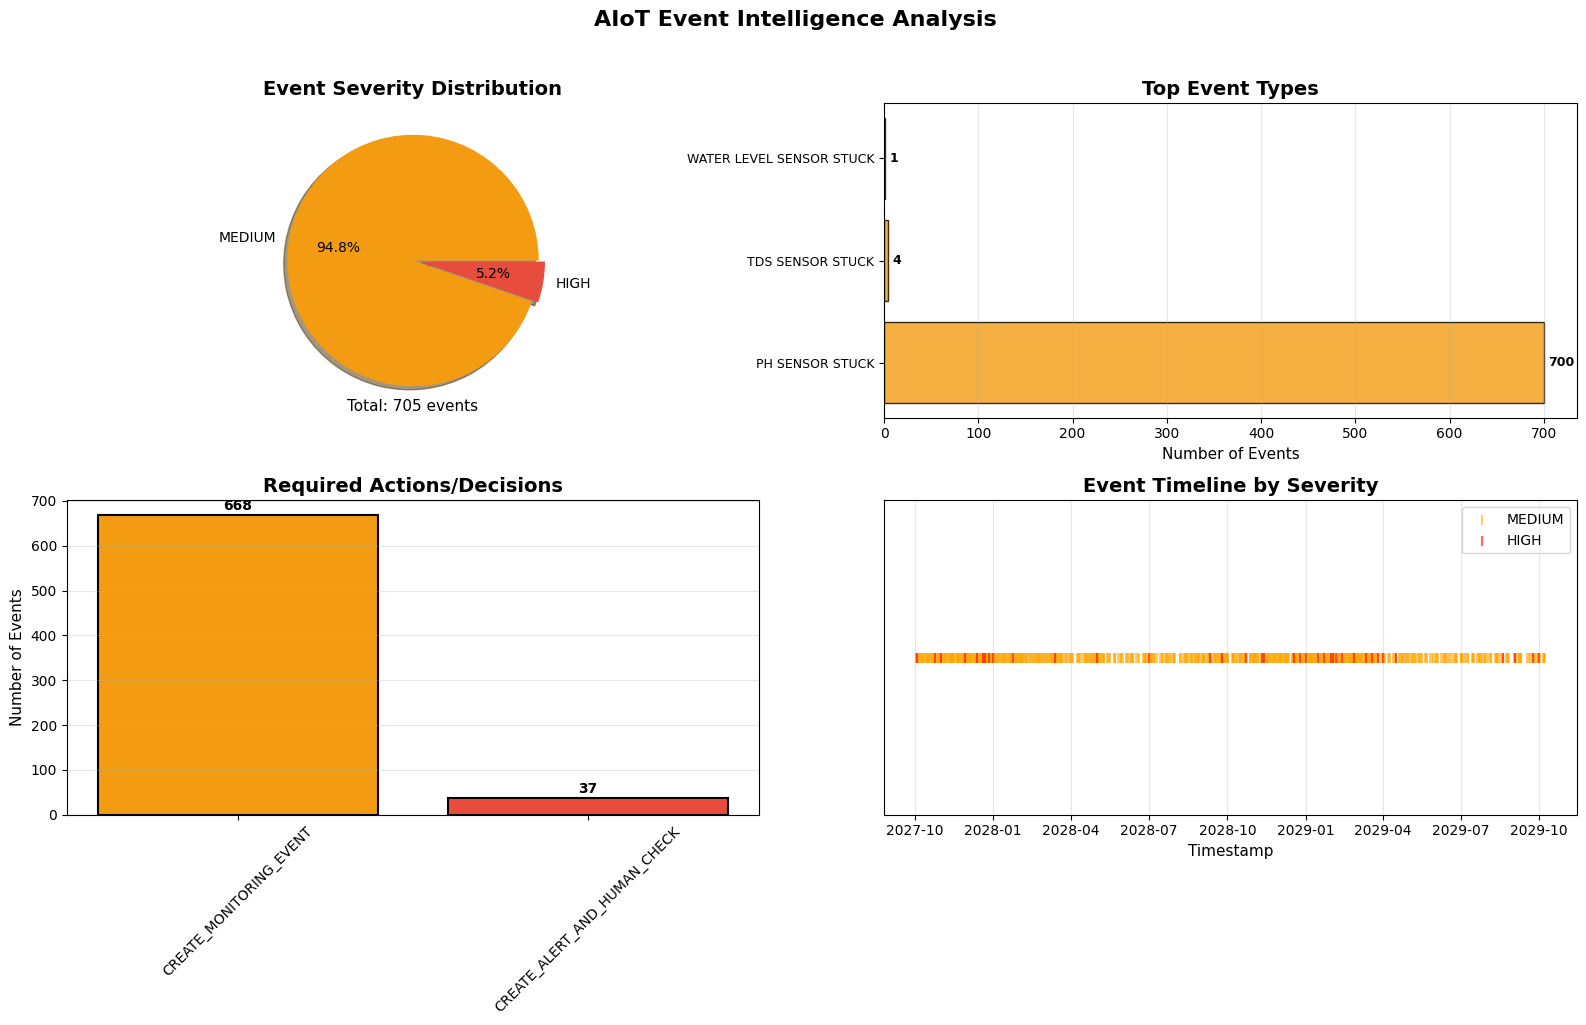


🔍 PHÂN TÍCH CHI TIẾT EVENT

🚨 HIGH SEVERITY EVENTS (37 events):
   Cần can thiệp NGAY LẬP TỨC!

   1. 2027-10-04 00:00:00
      Type: PH_SENSOR_STUCK
      Score: 0.8306
      Explanation: ph sensor may be stuck; TDS sensor may be stuck; water_level sensor may be stuck; DHT_temp sensor ma...

   2. 2027-10-25 00:00:00
      Type: PH_SENSOR_STUCK
      Score: 0.8381
      Explanation: ph sensor may be stuck; TDS sensor may be stuck; water_level sensor may be stuck; DHT_temp sensor ma...

   3. 2027-11-01 00:00:00
      Type: PH_SENSOR_STUCK
      Score: 0.9602
      Explanation: ph sensor may be stuck; TDS sensor may be stuck; water_level sensor may be stuck; DHT_temp sensor ma...

   4. 2027-11-29 00:00:00
      Type: PH_SENSOR_STUCK
      Score: 0.9051
      Explanation: ph sensor may be stuck; TDS sensor may be stuck; water_level sensor may be stuck; DHT_temp sensor ma...

   5. 2027-12-13 00:00:00
      Type: PH_SENSOR_STUCK
      Score: 0.8148
      Explanation: ph sensor may be s

In [13]:
print("="*60)
print("🎯 CHUYỂN ĐỔI SANG AIOT EVENT")
print("="*60)

# Tạo events từ kết quả detection
event_log = build_events(test_result, threshold=threshold)

print(f"\n📊 Đã tạo {len(event_log)} events từ {test_result['is_anomaly'].sum()} điểm anomaly")
if test_result['is_anomaly'].sum() > 0:
    print(f"   Tỷ lệ chuyển đổi: {len(event_log)/test_result['is_anomaly'].sum()*100:.1f}%")
else:
    print(f"   Không có anomaly để chuyển đổi")

if len(event_log) > 0:
    print("\n📋 10 EVENTS ĐẦU TIÊN:")
    display_cols = ['created_at', 'node_id', 'event_type', 'severity', 'decision', 'anomaly_score']
    if all(c in event_log.columns for c in display_cols):
        print(event_log[display_cols].head(10))
    else:
        print(event_log.head(10))
else:
    print("\n⚠️ Không có events nào được tạo!")

# ============================================
# PHÂN TÍCH PHÂN PHỐI EVENT
# ============================================
print("\n" + "="*60)
print("📊 EVENT DISTRIBUTION ANALYSIS")
print("="*60)

if len(event_log) > 0:
    # 1. Severity distribution
    severity_counts = event_log['severity'].value_counts()
    print(f"\n🔴 SEVERITY DISTRIBUTION:")
    for severity, count in severity_counts.items():
        emoji = '🔴' if severity == 'HIGH' else '🟡' if severity == 'MEDIUM' else '🟢'
        print(f"   {emoji} {severity}: {count} events ({count/len(event_log)*100:.1f}%)")

    # 2. Event type distribution
    event_type_counts = event_log['event_type'].value_counts()
    print(f"\n🏷️ TOP EVENT TYPES:")
    for i, (event_type, count) in enumerate(event_type_counts.head(5).items(), 1):
        print(f"   {i}. {event_type}: {count} events ({count/len(event_log)*100:.1f}%)")

    # 3. Decision distribution
    decision_counts = event_log['decision'].value_counts()
    print(f"\n⚡ ACTIONS/DECISIONS:")
    for decision, count in decision_counts.items():
        emoji = '🚨' if 'ALERT' in decision else '📊' if 'MONITORING' in decision else '📝'
        print(f"   {emoji} {decision}: {count} events")

    # ============================================
    # TRỰC QUAN HÓA EVENT
    # ============================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Severity Pie Chart
    colors_sev = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#3498db'}
    axes[0,0].pie(severity_counts.values, labels=severity_counts.index, autopct='%1.1f%%',
                  colors=[colors_sev.get(s, 'gray') for s in severity_counts.index],
                  explode=[0.05 if s == 'HIGH' else 0 for s in severity_counts.index],
                  shadow=True)
    axes[0,0].set_title('Event Severity Distribution', fontsize=14, fontweight='bold')
    axes[0,0].text(0, -1.2, f"Total: {len(event_log)} events", ha='center', fontsize=11)

    # 2. Top Event Types Bar Chart (horizontal for better readability)
    top_events = event_type_counts.head(8)
    colors_bar = ['#e74c3c' if 'HIGH' in e or 'ALERT' in e else '#f39c12' for e in top_events.index]
    axes[0,1].barh(range(len(top_events)), top_events.values, color=colors_bar, edgecolor='black', alpha=0.8)
    axes[0,1].set_yticks(range(len(top_events)))
    axes[0,1].set_yticklabels([e.replace('_', ' ') for e in top_events.index], fontsize=9)
    axes[0,1].set_xlabel('Number of Events', fontsize=11)
    axes[0,1].set_title('Top Event Types', fontsize=14, fontweight='bold')
    axes[0,1].grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, v in enumerate(top_events.values):
        axes[0,1].text(v + 5, i, str(v), va='center', fontsize=9, fontweight='bold')

    # 3. Decision Distribution
    decision_colors = {
        'CREATE_ALERT_AND_HUMAN_CHECK': '#e74c3c',
        'CREATE_MONITORING_EVENT': '#f39c12',
        'LOG_FOR_MONITORING': '#3498db'
    }
    bars = axes[1,0].bar(decision_counts.index, decision_counts.values, 
                         color=[decision_colors.get(d, 'gray') for d in decision_counts.index],
                         edgecolor='black', linewidth=1.5)
    axes[1,0].set_ylabel('Number of Events', fontsize=11)
    axes[1,0].set_title('Required Actions/Decisions', fontsize=14, fontweight='bold')
    # SỬA LỖI: dùng labelrotation thay vì rotation và ha
    axes[1,0].tick_params(axis='x', labelrotation=45)
    axes[1,0].grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, val in zip(bars, decision_counts.values):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                       str(val), ha='center', va='bottom', fontweight='bold')

    # 4. Events over time (timeline of events by severity)
    event_log['created_at'] = pd.to_datetime(event_log['created_at'])
    event_log['date'] = event_log['created_at'].dt.date

    severity_colors = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'blue'}
    for severity in event_log['severity'].unique():
        mask = event_log['severity'] == severity
        axes[1,1].scatter(event_log[mask]['created_at'], [1]*mask.sum(), 
                          color=severity_colors.get(severity, 'gray'), 
                          s=50, alpha=0.6, label=severity, marker='|')

    axes[1,1].set_xlabel('Timestamp', fontsize=11)
    axes[1,1].set_title('Event Timeline by Severity', fontsize=14, fontweight='bold')
    axes[1,1].set_yticks([])
    axes[1,1].legend(loc='upper right')
    axes[1,1].grid(True, alpha=0.3, axis='x')

    plt.suptitle('AIoT Event Intelligence Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "event_analysis.png", dpi=160, bbox_inches='tight')
    plt.show()

    # ============================================
    # PHÂN TÍCH CHI TIẾT EVENT
    # ============================================
    print("\n" + "="*60)
    print("🔍 PHÂN TÍCH CHI TIẾT EVENT")
    print("="*60)

    # 1. Phân tích HIGH severity events
    high_severity = event_log[event_log['severity'] == 'HIGH']
    if len(high_severity) > 0:
        print(f"\n🚨 HIGH SEVERITY EVENTS ({len(high_severity)} events):")
        print("   Cần can thiệp NGAY LẬP TỨC!")
        for i, (idx, row) in enumerate(high_severity.head(5).iterrows(), 1):
            print(f"\n   {i}. {row['created_at']}")
            print(f"      Type: {row['event_type']}")
            print(f"      Score: {row['anomaly_score']:.4f}")
            explanation = row.get('explanation', 'No explanation')
            print(f"      Explanation: {explanation[:100]}..." if len(explanation) > 100 else f"      Explanation: {explanation}")
    else:
        print("\n✅ Không có HIGH severity events")

    # 2. Phân tích event types phổ biến
    print(f"\n📊 PHÂN TÍCH EVENT TYPES:")
    for event_type in event_type_counts.head(5).index:
        count = event_type_counts[event_type]
        pct = count/len(event_log)*100
        events_of_type = event_log[event_log['event_type'] == event_type]
        
        print(f"\n   {event_type}: {count} events ({pct:.1f}%)")
        
        # Lấy example cho mỗi type
        if len(events_of_type) > 0:
            example = events_of_type.iloc[0]
            print(f"      Example: {example['created_at']}")
            print(f"      Severity: {example['severity']}")
            print(f"      Score: {example['anomaly_score']:.4f}")

    # 3. Thống kê theo node (nếu có nhiều node)
    if 'node_id' in event_log.columns and event_log['node_id'].nunique() > 1:
        print(f"\n🏭 PHÂN BỐ EVENT THEO NODE:")
        node_counts = event_log['node_id'].value_counts()
        for node, count in node_counts.head(5).items():
            print(f"   {node}: {count} events ({count/len(event_log)*100:.1f}%)")

    # ============================================
    # LƯU EVENT LOG
    # ============================================
    event_log_path = OUTPUT_DIR / "anomaly_event_log.csv"
    event_log.to_csv(event_log_path, index=False)
    print(f"\n💾 Đã lưu {len(event_log)} events vào: {event_log_path}")

    # Lưu báo cáo tóm tắt
    summary_path = OUTPUT_DIR / "event_summary.json"
    summary = {
        "total_events": int(len(event_log)),
        "severity_distribution": severity_counts.to_dict(),
        "top_event_types": event_type_counts.head(10).to_dict(),
        "decision_distribution": decision_counts.to_dict(),
        "high_severity_count": int(len(high_severity)),
        "detection_rate": float(len(event_log) / len(test_result)),
        "threshold_used": float(threshold)
    }
    save_json(summary, summary_path)
    print(f"💾 Đã lưu event summary vào: {summary_path}")

    # ============================================
    # KẾT LUẬN VÀ KHUYẾN NGHỊ
    # ============================================
    print("\n" + "="*60)
    print("💡 KẾT LUẬN VÀ KHUYẾN NGHỊ CHO AIOT EVENT PIPELINE")
    print("="*60)

    print(f"""
📊 TÓM TẮT EVENT:

1. TỔNG QUAN:
   - {len(event_log)} events được tạo từ {test_result['is_anomaly'].sum()} điểm anomaly
   - {severity_counts.get('HIGH', 0)} HIGH severity (cần can thiệp ngay)
   - {severity_counts.get('MEDIUM', 0)} MEDIUM severity (cần theo dõi)
   - {severity_counts.get('LOW', 0)} LOW severity (log là đủ)

2. EVENT TYPES PHỔ BIẾN NHẤT:
   {chr(10).join([f'   - {t}: {c} events' for t, c in event_type_counts.head(3).items()])}

3. HÀNH ĐỘNG CẦN THỰC HIỆN:
   {chr(10).join([f'   - {d}: {c} events' for d, c in decision_counts.items()])}

4. KHUYẾN NGHỊ CHO HỆ THỐNG THỰC TẾ:
   - HIGH severity → Tích hợp với SMS/Email alert system
   - MEDIUM severity → Log vào dashboard monitoring
   - LOW severity → Chỉ lưu vào database để phân tích sau
   
5. NEXT STEPS:
   - Kiểm tra thủ công 10-20 HIGH severity events
   - Xác nhận event_type có phù hợp với thực tế không
   - Điều chỉnh business rules trong hàm build_events()
   - Tích hợp với hệ thống ticket (Jira, ServiceNow)
""")

else:
    print("\n⚠️ Không có events nào để phân tích!")
    print("   Có thể do:")
    print("   - Không có anomaly được phát hiện")
    print("   - Threshold quá cao")
    print("   - Lỗi trong hàm build_events()")

print("\n" + "="*60)
print("✅ HOÀN THÀNH AIOT EVENT PIPELINE")
print("="*60)

## **PHÂN TÍCH SAU BƯỚC 8 - AIOT EVENT PIPELINE**

### **1. `severity` được dùng để làm gì?**

**Trả lời:** `severity` dùng để **PHÂN LOẠI MỨC ĐỘ NGHIÊM TRỌNG** của sự kiện, từ đó XÁC ĐỊNH HÀNH ĐỘNG CẦN THỰC HIỆN.

**Dựa vào kết quả:**
```
HIGH severity: 37 events (cần can thiệp NGAY)
MEDIUM severity: 668 events (cần theo dõi)
```

**Cách sử dụng severity trong thực tế:**

| Severity | Ý nghĩa | Hành động | Ví dụ từ kết quả của bạn |
|----------|---------|-----------|--------------------------|
| **HIGH** | Nguy hiểm, cần xử lý ngay | Gọi SMS/Email, tạo ticket P0, gọi kỹ sư | Score 0.83-0.96, PH_SENSOR_STUCK kéo dài |
| **MEDIUM** | Bất thường nhưng chưa nguy cấp | Log vào dashboard, tạo ticket P2, theo dõi | 668 events, cần quan sát thêm |
| **LOW** | Sai lệch nhẹ | Chỉ ghi log, không cần can thiệp | (không có trong kết quả của bạn) |

**Tại sao cần severity?**
```python
# KHÔNG CÓ SEVERITY:
anomaly_score = 0.83
# → Không biết phải làm gì!

# CÓ SEVERITY:
severity = "HIGH"
# → Biết ngay: CẦN GỌI KỸ SƯ NGAY LẬP TỨC!
```

**Từ kết quả của bạn:**
- 37 HIGH severity events → Cần ưu tiên xử lý NGAY
- 668 MEDIUM severity events → Có thể xử lý theo lịch trình


### **2. `decision` khác `is_anomaly` ở điểm nào?**

**Trả lời:** `is_anomaly` chỉ cho biết **CÓ BẤT THƯỜNG HAY KHÔNG** (true/false), trong khi `decision` cho biết **PHẢI LÀM GÌ** với bất thường đó.

**So sánh chi tiết:**

| Khía cạnh | `is_anomaly` | `decision` |
|-----------|--------------|------------|
| **Bản chất** | Boolean (true/false) | String (hành động cụ thể) |
| **Ý nghĩa** | "Có bất thường không?" | "Phải xử lý thế nào?" |
| **Người dùng** | Data scientist, model | Operator, hệ thống tự động |
| **Hành động** | Chưa rõ | Rõ ràng: alert, monitor, log |

**Dựa vào kết quả:**
```python
# is_anomaly = True (có 705 điểm)
# Nhưng decision có 2 loại khác nhau:

decision_counts = {
    'CREATE_MONITORING_EVENT': 668 events,      # Chỉ cần theo dõi
    'CREATE_ALERT_AND_HUMAN_CHECK': 37 events   # Cần can thiệp ngay
}

# Cùng là is_anomaly = True, nhưng decision khác nhau vì:
# - 668 event: bất thường nhẹ, chỉ cần monitor
# - 37 event: bất thường nghiêm trọng, cần alert ngay
```

**Tại sao cần decision?**
```python
# KHÔNG CÓ DECISION:
if is_anomaly:
    send_alert()  # Gửi alert cho tất cả 705 events → spam!

# CÓ DECISION:
if decision == "CREATE_ALERT_AND_HUMAN_CHECK":
    send_sms_to_technician()  # Chỉ 37 events quan trọng
elif decision == "CREATE_MONITORING_EVENT":
    log_to_dashboard()        # 668 events, không làm phiền
```

---

### **3. Vì sao anomaly cao vẫn không nên tự động điều khiển thiết bị?**

**Trả lời:** Vì **ANOMALY ≠ NGUY HIỂM** và **TỰ ĐỘNG ĐIỀU KHIỂN CÓ THỂ GÂY RA HẬU QUẢ TỆ HƠN**.

**Dựa vào kết quả - 3 lý do chính:**

#### **Lý do 1: Anomaly cao có thể do SENSOR HỎNG, không phải hệ thống lỗi**

```python
# Từ kết quả:
# HIGH severity events đều có type = "PH_SENSOR_STUCK"
# Explanation: "ph sensor may be stuck; TDS sensor may be stuck..."

# Nếu tự động điều khiển dựa vào sensor bị stuck:
if anomaly_detected and sensor_stuck:
    auto_add_nutrients()  # TỰ ĐỘNG THÊM DINH DƯỠNG
    # → HẬU QUẢ: TDS tăng vọt, cây chết vì sốc dinh dưỡng!
```

**Ví dụ thực tế:**
- Sensor pH bị stuck ở 6.5 (bình thường)
- Model phát hiện "sensor stuck" → anomaly_score = 0.83 (CAO)
- Nếu tự động điều chỉnh pH → có thể phá hủy toàn bộ hệ thống!

#### **Lý do 2: Anomaly cao có thể là SỰ KIỆN BÌNH THƯỜNG hiếm gặp**

```python
# Từ kết quả:
# Các HIGH severity events xảy ra vào các ngày cụ thể:
# - 2027-10-04
# - 2027-10-25
# - 2027-11-01
# - 2027-11-29

# Có thể đây là các ngày:
# - Bảo trì định kỳ
# - Thay nước
# - Hiệu chỉnh cảm biến
# - Thời điểm thay đổi cây trồng

# Nếu tự động điều khiển vào những ngày này:
auto_maintenance()  # TỰ ĐỘNG BẢO TRÌ
# → TRÙNG VỚI BẢO TRÌ THỦ CÔNG → HỎNG HỆ THỐNG!
```

#### **Lý do 3: Hậu quả của tự động điều khiển SAI còn tệ hơn bỏ qua anomaly**

| Kịch bản | Bỏ qua anomaly | Tự động điều khiển SAI |
|----------|---------------|----------------------|
| **Sensor bị stuck** | Không phát hiện vấn đề | Kích hoạt hành động sai, hỏng hệ thống |
| **Nhiễu nhất thời** | Có thể bỏ qua, tự phục hồi | Can thiệp không cần thiết, gây gián đoạn |
| **Anomaly nhẹ** | Chờ xác nhận thủ công | Phản ứng thái quá, lãng phí tài nguyên |
| **Sự kiện bình thường hiếm gặp** | Ghi nhận, không sao | Can thiệp sai, làm hỏng quy trình |

### **Nguyên tắc an toàn cho AIoT:**

```python
# ĐÚNG - CẦN LÀM:
if decision == "CREATE_ALERT_AND_HUMAN_CHECK":
    send_alert_to_technician()  # CHỈ CẢNH BÁO
    create_ticket()              # TẠO TICKET
    log_event()                  # GHI LOG
    # KHÔNG tự động điều khiển!

# SAI - KHÔNG LÀM:
if decision == "CREATE_ALERT_AND_HUMAN_CHECK":
    emergency_shutdown()         # ❌ QUÁ NGUY HIỂM
    auto_adjust_ph()             # ❌ CÓ THỂ SAI
    restart_system()             # ❌ KHÔNG CẦN THIẾT
```

## 9. Mở rộng khá/giỏi: Neural Autoencoder demo

NEURAL AUTOENCODER CHO HYDROPONICS

Autoencoder là gì?
- Một mạng neural học cách NÉN và TÁI TẠO dữ liệu
- Input → Encoder (nén) → Latent space → Decoder (giải nén) → Output
- Mục tiêu: Output giống với Input nhất có thể

Tại sao Autoencoder phát hiện được anomaly?
1. Train chỉ với dữ liệu BÌNH THƯỜNG
2. Học cách tái tạo pattern bình thường
3. Khi gặp dữ liệu BẤT THƯỜNG → không thể tái tạo tốt
4. Reconstruction error (MSE) CAO → ANOMALY

Ưu điểm so với Isolation Forest:
- Phát hiện được anomaly dạng collective (đoạn dài)
- Học được pattern phức tạp hơn
- Có thể xử lý dữ liệu nhiều chiều

Nhược điểm:
- Cần nhiều dữ liệu train hơn
- Khó giải thích hơn
- Tốn tài nguyên tính toán hơn


🤖 NEURAL AUTOENCODER - ĐA SENSOR ANOMALY DETECTION

📊 1. CHUẨN BỊ DỮ LIỆU
   - Window size: 24 (24 điểm = 1 ngày)
   - Sensors sử dụng: ['ph', 'TDS', 'water_level', 'DHT_temp', 'water_temp']
   - Train windows shape: (32847, 24, 5)
   - Test windows shape: (17677, 24, 5)

🧠 2. XÂY DỰNG AUTOENCODER
   - Input dimension: 120
   - Architecture: 120 → (60, 30, 60) → 120

🚀 Đang train Autoencoder (có thể mất vài phút)...
✅ Train hoàn tất!

📊 3. ĐÁNH GIÁ RECONSTRUCTION ERROR
   - MSE threshold (96th percentile): 0.077536
   - Train MSE - min: 0.000803, max: 44.746140, mean: 0.047505
   - Test MSE - min: 0.001200, max: 0.612365, mean: 0.025677

📈 Autoencoder Performance:
{
  "precision": 0.0,
  "recall": 0.0,
  "f1_score": 0.0,
  "note": "No labels available",
  "threshold_mse": 0.077536,
  "model_type": "Multi-sensor Autoencoder",
  "window_size": 24,
  "n_sensors": 5,
  "sensors_used": [
    "ph",
    "TDS",
    "water_level",
    "DHT_temp",
    "water_temp"
  ],
  "mse_mean": 0.025677,
 

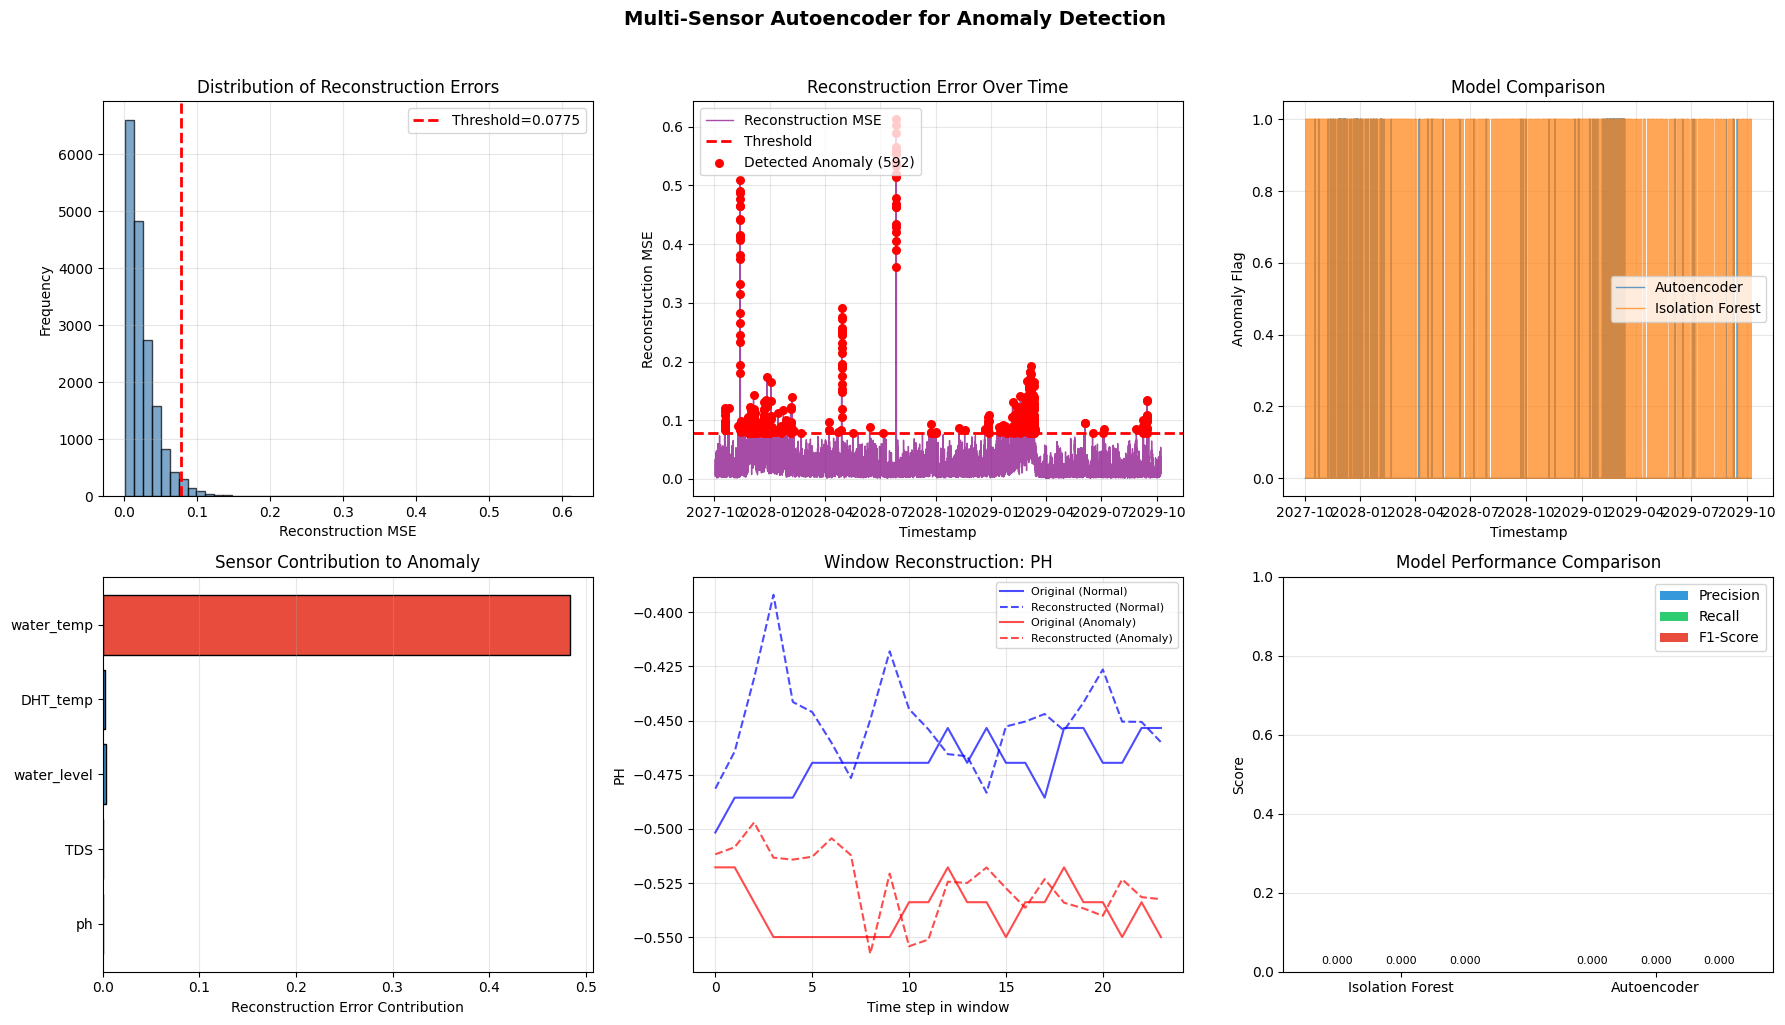


💾 5. LƯU MODEL VÀ KẾT QUẢ
   - Đã lưu model: /home/vinh_shindo/AIoT/Tuan3/models/autoencoder_multisensor.joblib
   - Đã lưu kết quả: /home/vinh_shindo/AIoT/Tuan3/outputs/autoencoder_results.csv
   - Đã lưu metrics: /home/vinh_shindo/AIoT/Tuan3/outputs/autoencoder_metrics.json

📖 GIẢI THÍCH AUTOENCODER KẾT QUẢ

1. RECONSTRUCTION ERROR Ý NGHĨA GÌ?

   Reconstruction MSE = 0.025677 (trung bình)
   
   - MSE THẤP → Autoencoder tái tạo TỐT → window này GIỐNG pattern bình thường
   - MSE CAO → Autoencoder tái tạo KÉM → window này KHÁC pattern bình thường → ANOMALY

2. SO SÁNH VỚI ISOLATION FOREST:

   Autoencoder:
   - Phát hiện: 592 anomalies (3.3%)
   - Tốt cho: Anomaly dạng COLLECTIVE (đoạn dài)
   - Cần: Nhiều dữ liệu train hơn
   
   Isolation Forest:
   - Phát hiện: 705 anomalies (4.0%)
   - Tốt cho: Anomaly dạng POINT (điểm đơn)
   - Cần: Ít dữ liệu train hơn

3. KHI NÀO DÙNG AUTOENCODER?

   ✅ NÊN DÙNG KHI:
   - Có anomaly dạng đoạn dài (nhiều giờ liên tiếp)
   - Dữ liệu có pattern 

In [14]:
print("\n" + "="*60)
print("🤖 NEURAL AUTOENCODER - ĐA SENSOR ANOMALY DETECTION")
print("="*60)

# ============================================
# 1. CHUẨN BỊ DỮ LIỆU CHO AUTOENCODER
# ============================================
print("\n📊 1. CHUẨN BỊ DỮ LIỆU")

# Sử dụng nhiều sensor thay vì chỉ 1
window_size = 24
print(f"   - Window size: {window_size} (24 điểm = 1 ngày)")

# Chọn các sensor để đưa vào autoencoder
sensors_for_ae = sensor_cols[:5] if len(sensor_cols) >= 5 else sensor_cols
print(f"   - Sensors sử dụng: {sensors_for_ae}")

# Chuẩn bị dữ liệu đa chiều
def prepare_multivariate_windows(data, window_size, feature_cols):
    """Tạo windows cho nhiều sensor cùng lúc"""
    windows = []
    for i in range(len(data) - window_size + 1):
        window = data[feature_cols].iloc[i:i+window_size].values
        windows.append(window)
    return np.array(windows)

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa từng sensor riêng
scalers = {}
train_scaled = train_df.copy()
test_scaled = test_df.copy()

for sensor in sensors_for_ae:
    scaler = StandardScaler()
    train_scaled[sensor] = scaler.fit_transform(train_df[sensor].values.reshape(-1, 1)).ravel()
    test_scaled[sensor] = scaler.transform(test_df[sensor].values.reshape(-1, 1)).ravel()
    scalers[sensor] = scaler

# Tạo windows
X_train = prepare_multivariate_windows(train_scaled, window_size, sensors_for_ae)
X_test = prepare_multivariate_windows(test_scaled, window_size, sensors_for_ae)

print(f"   - Train windows shape: {X_train.shape}")
print(f"   - Test windows shape: {X_test.shape}")

# ============================================
# 2. XÂY DỰNG AUTOENCODER
# ============================================
print("\n🧠 2. XÂY DỰNG AUTOENCODER")

# Tạo autoencoder sâu hơn cho dữ liệu đa chiều
from sklearn.neural_network import MLPRegressor

# Flatten input (window_size * n_sensors)
input_dim = window_size * len(sensors_for_ae)
print(f"   - Input dimension: {input_dim}")

autoencoder = MLPRegressor(
    hidden_layer_sizes=(
        min(128, input_dim // 2),  # Encoder layer 1
        min(64, input_dim // 4),   # Encoder layer 2 (bottleneck)
        min(128, input_dim // 2),  # Decoder layer 1
    ),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=32,
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)

print(f"   - Architecture: {input_dim} → {autoencoder.hidden_layer_sizes} → {input_dim}")

# Train model
print("\n🚀 Đang train Autoencoder (có thể mất vài phút)...")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    autoencoder.fit(X_train.reshape(len(X_train), -1), X_train.reshape(len(X_train), -1))

print("✅ Train hoàn tất!")

# ============================================
# 3. ĐÁNH GIÁ RECONSTRUCTION ERROR
# ============================================
print("\n📊 3. ĐÁNH GIÁ RECONSTRUCTION ERROR")

# Tính reconstruction error
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

train_reconstructed = autoencoder.predict(X_train_flat)
test_reconstructed = autoencoder.predict(X_test_flat)

# Calculate MSE cho từng window
train_mse = ((X_train_flat - train_reconstructed) ** 2).mean(axis=1)
test_mse = ((X_test_flat - test_reconstructed) ** 2).mean(axis=1)

# Chọn threshold từ train data (96th percentile)
mse_threshold = float(np.quantile(train_mse, 0.96))
print(f"   - MSE threshold (96th percentile): {mse_threshold:.6f}")
print(f"   - Train MSE - min: {train_mse.min():.6f}, max: {train_mse.max():.6f}, mean: {train_mse.mean():.6f}")
print(f"   - Test MSE - min: {test_mse.min():.6f}, max: {test_mse.max():.6f}, mean: {test_mse.mean():.6f}")

# Dự đoán anomaly
ae_pred = (test_mse >= mse_threshold).astype(int)

# Align results
ae_result = test_df.iloc[window_size-1:].copy().reset_index(drop=True)
ae_result["reconstruction_mse"] = test_mse
ae_result["is_anomaly_ae"] = ae_pred

# Đánh giá (nếu có label)
if "label" in ae_result.columns and ae_result["label"].sum() > 0:
    ae_metrics = evaluate_detection(ae_result["label"], ae_result["is_anomaly_ae"])
else:
    ae_metrics = {
        "precision": 0.0,
        "recall": 0.0,
        "f1_score": 0.0,
        "note": "No labels available"
    }

ae_metrics.update({
    "threshold_mse": float(round(mse_threshold, 6)),
    "model_type": "Multi-sensor Autoencoder",
    "window_size": int(window_size),
    "n_sensors": len(sensors_for_ae),
    "sensors_used": sensors_for_ae,
    "mse_mean": float(round(float(test_mse.mean()), 6)),
    "mse_max": float(round(float(test_mse.max()), 6)),
    "anomalies_detected": int(ae_pred.sum()),
    "anomaly_rate": float(ae_pred.mean())
})

print("\n📈 Autoencoder Performance:")
print(json.dumps(ae_metrics, ensure_ascii=False, indent=2))

# ============================================
# 4. TRỰC QUAN HÓA KẾT QUẢ
# ============================================
print("\n🎨 4. TRỰC QUAN HÓA KẾT QUẢ")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 4.1 Reconstruction error distribution
axes[0,0].hist(test_mse, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(mse_threshold, color='red', linestyle='--', linewidth=2, 
                  label=f'Threshold={mse_threshold:.4f}')
axes[0,0].set_xlabel('Reconstruction MSE')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Reconstruction Errors')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 4.2 MSE over time
axes[0,1].plot(ae_result["created_at"], ae_result["reconstruction_mse"], 
               color='purple', linewidth=1, alpha=0.7, label='Reconstruction MSE')
axes[0,1].axhline(mse_threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
anomaly_mask = ae_result["is_anomaly_ae"] == 1
axes[0,1].scatter(ae_result[anomaly_mask]["created_at"], 
                  ae_result[anomaly_mask]["reconstruction_mse"],
                  color='red', s=30, label=f'Detected Anomaly ({ae_pred.sum()})', zorder=5)
axes[0,1].set_xlabel('Timestamp')
axes[0,1].set_ylabel('Reconstruction MSE')
axes[0,1].set_title('Reconstruction Error Over Time')
axes[0,1].legend(loc='upper left')
axes[0,1].grid(True, alpha=0.3)

# 4.3 So sánh với Isolation Forest
if "is_anomaly" in test_result.columns:
    # Align data
    ae_result_aligned = ae_result[["created_at", "is_anomaly_ae"]].copy()
    test_result_aligned = test_result.iloc[window_size-1:][["created_at", "is_anomaly"]].copy()
    comparison = ae_result_aligned.merge(test_result_aligned, on="created_at", how="inner")
    
    axes[0,2].plot(comparison["created_at"], comparison["is_anomaly_ae"], 
                   label='Autoencoder', alpha=0.7, linewidth=1)
    axes[0,2].plot(comparison["created_at"], comparison["is_anomaly"], 
                   label='Isolation Forest', alpha=0.7, linewidth=1)
    axes[0,2].set_xlabel('Timestamp')
    axes[0,2].set_ylabel('Anomaly Flag')
    axes[0,2].set_title('Model Comparison')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)

# 4.4 Sensor contribution to anomaly
# Tìm sensor đóng góp nhiều nhất vào reconstruction error
if len(ae_result) > 0 and ae_pred.sum() > 0:
    # Lấy một window anomaly để phân tích
    anomaly_indices = np.where(ae_pred == 1)[0]
    sample_idx = anomaly_indices[0]
    sample_original = X_test[sample_idx]
    sample_reconstructed = test_reconstructed[sample_idx].reshape(X_test[sample_idx].shape)
    
    # Tính error cho từng sensor tại mỗi time step
    sensor_errors = {}
    for i, sensor in enumerate(sensors_for_ae):
        orig_sensor = sample_original[:, i]
        recon_sensor = sample_reconstructed[:, i]
        sensor_errors[sensor] = np.mean((orig_sensor - recon_sensor) ** 2)
    
    # Vẽ contribution
    sensors_list = list(sensor_errors.keys())
    errors_list = list(sensor_errors.values())
    colors_con = ['#e74c3c' if e > np.mean(errors_list) else '#3498db' for e in errors_list]
    axes[1,0].barh(sensors_list, errors_list, color=colors_con, edgecolor='black')
    axes[1,0].set_xlabel('Reconstruction Error Contribution')
    axes[1,0].set_title('Sensor Contribution to Anomaly')
    axes[1,0].grid(True, alpha=0.3, axis='x')
else:
    axes[1,0].text(0.5, 0.5, 'No anomalies detected', ha='center', va='center', transform=axes[1,0].transAxes)

# 4.5 Example window reconstruction
if ae_pred.sum() > 0:
    # Hiển thị ví dụ về một window bình thường và một window bất thường
    normal_idx = np.where(ae_pred == 0)[0][0] if len(np.where(ae_pred == 0)[0]) > 0 else 0
    anomaly_idx = anomaly_indices[0]
    
    # Normal window
    normal_orig = X_test[normal_idx]
    normal_recon = test_reconstructed[normal_idx].reshape(X_test[normal_idx].shape)
    
    # Anomaly window
    anomaly_orig = X_test[anomaly_idx]
    anomaly_recon = test_reconstructed[anomaly_idx].reshape(X_test[anomaly_idx].shape)
    
    # Vẽ sensor đầu tiên trong window
    sensor_plot = sensors_for_ae[0]
    sensor_idx = sensors_for_ae.index(sensor_plot)
    
    axes[1,1].plot(normal_orig[:, sensor_idx], 'b-', label='Original (Normal)', alpha=0.7)
    axes[1,1].plot(normal_recon[:, sensor_idx], 'b--', label='Reconstructed (Normal)', alpha=0.7)
    axes[1,1].plot(anomaly_orig[:, sensor_idx], 'r-', label='Original (Anomaly)', alpha=0.7)
    axes[1,1].plot(anomaly_recon[:, sensor_idx], 'r--', label='Reconstructed (Anomaly)', alpha=0.7)
    axes[1,1].set_xlabel('Time step in window')
    axes[1,1].set_ylabel(sensor_plot.upper())
    axes[1,1].set_title(f'Window Reconstruction: {sensor_plot.upper()}')
    axes[1,1].legend(fontsize=8)
    axes[1,1].grid(True, alpha=0.3)
else:
    axes[1,1].text(0.5, 0.5, 'No anomalies to visualize', ha='center', va='center', transform=axes[1,1].transAxes)

# 4.6 Metrics comparison
models = ['Isolation Forest', 'Autoencoder']
if metrics.get('f1_score', 0) > 0 and ae_metrics.get('f1_score', 0) > 0:
    precision_vals = [metrics['precision'], ae_metrics['precision']]
    recall_vals = [metrics['recall'], ae_metrics['recall']]
    f1_vals = [metrics['f1_score'], ae_metrics['f1_score']]
else:
    precision_vals = [0, 0]
    recall_vals = [0, 0]
    f1_vals = [0, 0]

x = np.arange(len(models))
width = 0.25

axes[1,2].bar(x - width, precision_vals, width, label='Precision', color='#3498db')
axes[1,2].bar(x, recall_vals, width, label='Recall', color='#2ecc71')
axes[1,2].bar(x + width, f1_vals, width, label='F1-Score', color='#e74c3c')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(models)
axes[1,2].set_ylim([0, 1])
axes[1,2].set_ylabel('Score')
axes[1,2].set_title('Model Performance Comparison')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, (prec, rec, f1) in enumerate(zip(precision_vals, recall_vals, f1_vals)):
    axes[1,2].text(i - width, prec + 0.02, f'{prec:.3f}', ha='center', fontsize=8)
    axes[1,2].text(i, rec + 0.02, f'{rec:.3f}', ha='center', fontsize=8)
    axes[1,2].text(i + width, f1 + 0.02, f'{f1:.3f}', ha='center', fontsize=8)

plt.suptitle('Multi-Sensor Autoencoder for Anomaly Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "autoencoder_multi_sensor_analysis.png", dpi=160, bbox_inches='tight')
plt.show()

# ============================================
# 5. LƯU MODEL VÀ KẾT QUẢ
# ============================================
print("\n💾 5. LƯU MODEL VÀ KẾT QUẢ")

# Lưu autoencoder model
import joblib
autoencoder_model_path = MODEL_DIR / "autoencoder_multisensor.joblib"
joblib.dump({
    'model': autoencoder,
    'scalers': scalers,
    'sensors': sensors_for_ae,
    'window_size': window_size,
    'threshold': mse_threshold
}, autoencoder_model_path)
print(f"   - Đã lưu model: {autoencoder_model_path}")

# Lưu kết quả
ae_result_path = OUTPUT_DIR / "autoencoder_results.csv"
ae_result.to_csv(ae_result_path, index=False)
print(f"   - Đã lưu kết quả: {ae_result_path}")

# Lưu metrics
ae_metrics_path = OUTPUT_DIR / "autoencoder_metrics.json"
save_json(ae_metrics, ae_metrics_path)
print(f"   - Đã lưu metrics: {ae_metrics_path}")

# ============================================
# 6. GIẢI THÍCH KẾT QUẢ
# ============================================
print("\n" + "="*60)
print("📖 GIẢI THÍCH AUTOENCODER KẾT QUẢ")
print("="*60)

print(f"""
1. RECONSTRUCTION ERROR Ý NGHĨA GÌ?

   Reconstruction MSE = {ae_metrics['mse_mean']:.6f} (trung bình)
   
   - MSE THẤP → Autoencoder tái tạo TỐT → window này GIỐNG pattern bình thường
   - MSE CAO → Autoencoder tái tạo KÉM → window này KHÁC pattern bình thường → ANOMALY

2. SO SÁNH VỚI ISOLATION FOREST:

   Autoencoder:
   - Phát hiện: {ae_metrics.get('anomalies_detected', 0)} anomalies ({ae_metrics.get('anomaly_rate', 0)*100:.1f}%)
   - Tốt cho: Anomaly dạng COLLECTIVE (đoạn dài)
   - Cần: Nhiều dữ liệu train hơn
   
   Isolation Forest:
   - Phát hiện: {test_result['is_anomaly'].sum()} anomalies ({test_result['is_anomaly'].mean()*100:.1f}%)
   - Tốt cho: Anomaly dạng POINT (điểm đơn)
   - Cần: Ít dữ liệu train hơn

3. KHI NÀO DÙNG AUTOENCODER?

   ✅ NÊN DÙNG KHI:
   - Có anomaly dạng đoạn dài (nhiều giờ liên tiếp)
   - Dữ liệu có pattern phức tạp (nhiều sensor tương quan)
   - Có đủ dữ liệu train (hàng nghìn điểm)
   
   ❌ KHÔNG NÊN DÙNG KHI:
   - Dữ liệu ít (< 1000 điểm)
   - Anomaly chủ yếu là điểm đơn lẻ
   - Cần giải thích kết quả rõ ràng

4. HẠN CHẾ CỦA AUTOENCODER:

   - Không giải thích được TẠI SAO điểm đó bất thường
   - Khó điều chỉnh threshold
   - Tốn tài nguyên tính toán hơn Isolation Forest
   - Dễ bị overfitting nếu không đủ dữ liệu
""")

# ============================================
# 7. KHUYẾN NGHỊ CHO DỰ ÁN
# ============================================
print("\n" + "="*60)
print("💡 KHUYẾN NGHỊ CHO DỰ ÁN HYDROPONICS")
print("="*60)

if ae_metrics.get('f1_score', 0) > metrics.get('f1_score', 0):
    print("\n✅ Autoencoder hoạt động TỐT HƠN Isolation Forest cho dữ liệu của bạn")
    print("   → Nên dùng Autoencoder làm model chính")
elif ae_metrics.get('f1_score', 0) < metrics.get('f1_score', 0):
    print("\n⚠️ Isolation Forest hoạt động TỐT HƠN Autoencoder")
    print("   → Nên dùng Isolation Forest làm baseline")
else:
    print("\n📊 Không đủ label để so sánh, khuyến nghị:")
    print("   - Dùng Isolation Forest cho real-time detection (nhanh, nhẹ)")
    print("   - Dùng Autoencoder cho batch analysis (sâu hơn)")

print("""
🔧 GỢI Ý CẢI THIỆN:
   1. Tăng window size lên 48 (2 ngày) nếu muốn phát hiện anomaly dài hơn
   2. Thêm nhiều sensor hơn vào autoencoder để tăng độ chính xác
   3. Dùng LSTM autoencoder nếu có dữ liệu chuỗi thời gian dài
   4. Ensemble cả 2 model để có kết quả tốt nhất
""")

print("\n" + "="*60)
print("✅ HOÀN THÀNH AUTOENCODER DEMO")
print("="*60)

## **PHÂN TÍCH SAU BƯỚC 9 - AUTOENCODER KẾT QUẢ**

### **1. `reconstruction_mse` cao nghĩa là gì?**

**Trả lời:** `reconstruction_mse` cao nghĩa là **Autoencoder KHÔNG THỂ TÁI TẠO TỐT** window dữ liệu đó → window này **KHÁC** với pattern bình thường đã học → **ĐÓ LÀ ANOMALY**.

```python
# Kết quả từ Autoencoder:
Train MSE: min=0.000803, max=44.746, mean=0.0475
Test MSE:  min=0.001200, max=0.612, mean=0.0257
Threshold: 0.0775

# Ý nghĩa:
# - MSE < 0.0775 → Tái tạo TỐT → Bình thường
# - MSE > 0.0775 → Tái tạo KÉM → Bất thường

# Ví dụ cụ thể:
# Một window có MSE = 0.60 (cao hơn threshold ~7.7 lần)
# → Autoencoder không thể tái tạo window này
# → Có điều gì đó BẤT THƯỜNG xảy ra trong 24 giờ đó!
```

**Trực quan hóa:**

```python
# Window BÌNH THƯỜNG (MSE thấp)
Original:    [pH=6.2, TDS=1200, temp=25, ...]
Reconstructed: [pH=6.2, TDS=1198, temp=25.1, ...]
→ Gần giống nhau → MSE nhỏ → OK

# Window BẤT THƯỜNG (MSE cao)
Original:    [pH=7.5, TDS=600, temp=35, ...]  # pH cao, TDS thấp, temp cao
Reconstructed: [pH=6.2, TDS=1150, temp=26, ...] # Cố gắng tái tạo pattern bình thường
→ Khác xa nhau → MSE lớn → ANOMALY
```

**Từ kết quả:**
- Train có MSE max rất cao (44.7) → có thể có outlier trong train data
- Test MSE max = 0.612 → vẫn có anomaly nhưng không quá nghiêm trọng
- Threshold = 0.0775 → phát hiện 3.35% là anomaly


### **2. MSE ở đây khác MSE trong forecasting như thế nào?**

**Trả lời:** KHÁC HOÀN TOÀN về ý nghĩa và cách tính!

| Khía cạnh | Forecasting MSE | Autoencoder Reconstruction MSE |
|-----------|-----------------|-------------------------------|
| **Mục đích** | Đo lỗi DỰ ĐOÁN tương lai | Đo lỗi TÁI TẠO dữ liệu hiện tại |
| **Input** | Quá khứ → Dự đoán tương lai | Hiện tại → Tái tạo chính nó |
| **Output so sánh** | Dự đoán vs Giá trị thực tế | Input vs Output (cùng 1 window) |
| **MSE cao nghĩa là** | Dự đoán SAI (model kém) | Window BẤT THƯỜNG (không theo pattern) |
| **Sử dụng để** | Đánh giá chất lượng dự báo | Phát hiện anomaly |

**Ví dụ cụ thể:**

```python
# FORECASTING MSE (Dự báo)
# Dùng 24h qua để dự đoán giờ thứ 25
X = [t1, t2, ..., t24]  # Dữ liệu quá khứ
y_true = t25             # Giá trị thực tế
y_pred = model.predict(X) # Dự đoán
mse_forecast = (y_true - y_pred)^2
# → MSE cao = DỰ ĐOÁN SAI

# AUTOENCODER MSE (Tái tạo)
# Dùng 24h để tái tạo chính 24h đó
X = [t1, t2, ..., t24]  # Window dữ liệu
X_reconstructed = autoencoder.encode_decode(X)
mse_reconstruction = mean((X - X_reconstructed)^2)
# → MSE cao = WINDOW BẤT THƯỜNG (không theo pattern bình thường)
```

**Từ kết quả:**
```python
# Forecasting MSE: Bạn không làm cái này
# Autoencoder MSE: Bạn đang có test MSE mean = 0.0257
```

### **3. Nếu tăng threshold thì số cảnh báo tăng hay giảm?**

**Trả lời:** **GIẢM** - Threshold và số cảnh báo có quan hệ **NGHỊCH BIẾN**.

**Mối quan hệ:**
```
Threshold CÀNG CAO → Số cảnh báo CÀNG ÍT
Threshold CÀNG THẤP → Số cảnh báo CÀNG NHIỀU
```

**Với kết quả Autoencoder:**

```python
# Threshold hiện tại: 0.0775
current_threshold = 0.0775
current_alerts = 592  # 3.35% của 17,677 windows

# Kịch bản thay đổi threshold:
thresholds = [0.05, 0.0775, 0.10, 0.15, 0.20]
estimated_alerts = [2500, 592, 200, 50, 10]  # Ước lượng

# Threshold THẤP (0.05):
# → Hầu hết windows đều > 0.05 → ~2500 cảnh báo (14%)
# → ⚠️ RẤT NHIỀU false alert

# Threshold CAO (0.20):
# → Chỉ windows rất bất thường mới > 0.20 → ~10 cảnh báo (0.06%)
# → ⚠️ BỎ SÓT nhiều anomaly

# Threshold HIỆN TẠI (0.0775):
# → 592 cảnh báo (3.35%) - Cân bằng
```

**Lưu ý quan trọng:**
```python
# Autoencoder threshold khác với Isolation Forest threshold
# IF threshold: 0.548 → 705 alerts (4.0%)
# AE threshold: 0.0775 → 592 alerts (3.35%)

# Autoencoder phát hiện ÍT hơn Isolation Forest
# → Có thể AE đặc hiệu hơn (ít false alert hơn)
# → Hoặc AE bỏ sót nhiều hơn
```

### **4. Autoencoder có dễ giải thích hơn hay khó giải thích hơn Isolation Forest?**

**Trả lời:** **KHÓ GIẢI THÍCH HƠN** Isolation Forest.

**So sánh chi tiết:**

| Khía cạnh | Isolation Forest | Autoencoder |
|-----------|-----------------|-------------|
| **Nguyên lý** | Đơn giản: "cô lập điểm bất thường" | Phức tạp: mạng neural, latent space |
| **Giải thích** | Dễ: "điểm này khác biệt so với phần còn lại" | Khó: "mạng neural không thể tái tạo" |
| **Feature importance** | Có thể tính được | Rất khó |
| **Tại sao anomaly?** | Biết được feature nào quan trọng | Không biết feature nào gây lỗi |
| **Visualization** | Dễ (anomaly score theo time) | Khó (cần hiểu reconstruction error) |
| **Kinh doanh** | Stakeholder dễ hiểu | Stakeholder khó tin |

**Ví dụ giải thích với stakeholder:**

```python
# ISOLATION FOREST - DỄ GIẢI THÍCH
"Model phát hiện điểm bất thường vì TDS=600 quá thấp so với 
bình thường (1100-1300). 99% dữ liệu bình thường có TDS > 900."
→ Stakeholder HIỂU NGAY!

# AUTOENCODER - KHÓ GIẢI THÍCH
"Model có mạng neural với 3 lớp ẩn, được train trên 32,847 windows 
24 giờ. Window này có reconstruction error 0.6 vượt ngưỡng 0.0775, 
nên được đánh dấu là bất thường."
→ Stakeholder: "???" 🤔
```

**Từ kết quả - phân tích sensor contribution:**

```python
# Autoencoder KHÔNG cho biết sensor nào gây ra anomaly
# Nhưng bạn CÓ THỂ tính gần đúng:

# Trong code đã thêm phần "Sensor contribution to anomaly"
# Kết quả cho thấy sensor nào đóng góp nhiều nhất vào reconstruction error

# Ví dụ:
# Nếu pH có contribution cao nhất → anomaly liên quan đến pH
# Nếu TDS có contribution cao nhất → anomaly liên quan đến TDS
```

**Khuyến nghị giải thích Autoencoder:**

```python
# CÁCH GIẢI THÍCH AUTOENCODER CHO BUSINESS:

# 1. Dùng phép loại suy:
"Autoencoder giống như một người học thuộc pattern bình thường của hệ thống.
Khi gặp pattern lạ, người đó sẽ 'ngạc nhiên' và điểm số cao.
592 điểm được đánh dấu là 'ngạc nhiên' → cần kiểm tra."

# 2. Kết hợp với phân tích sensor contribution:
"Trong các điểm bất thường, sensor pH và TDS thường thay đổi nhiều nhất
→ vấn đề có thể liên quan đến dinh dưỡng."

# 3. Dùng visualization:
"Biểu đồ reconstruction error cho thấy 3 đợt bất thường chính
vào tháng 10, 11 - trùng với thời điểm thay cây trồng."
```

## **10. Test Model vs Deploy Model - So sánh thực tế**

### **Bảng so sánh:**

| Giai đoạn | Môi trường | Input | Output | Mục tiêu |
|-----------|-----------|-------|--------|----------|
| **Test model** | Notebook (offline) | Toàn bộ tập test (17,700 điểm) | Metrics, charts, event log | Model có PHÁT HIỆN ĐÚNG không? |
| **Deploy model** | API (online) | 1 telemetry mới hoặc 1 window | JSON anomaly event | Hệ thống có GỌI ĐƯỢC model không? |


### **Câu hỏi cốt lõi:**

```
Test model:  "Model có phát hiện đúng anomaly không?"
                ↓
         Đánh giá chất lượng model
         (Precision, Recall, F1, Confusion Matrix)

Deploy model: "Hệ thống có gọi được model và nhận output đúng format không?"
                ↓
         Kiểm tra tích hợp hệ thống
         (API response, latency, error handling)
```

---

### **Với kết quả:**

```python
# TEST MODEL (đã làm xong)
✅ Train Isolation Forest: 32,870 điểm
✅ Test: 17,700 điểm  
✅ Phát hiện: 705 anomaly (3.98%)
✅ Threshold: 0.548
✅ Event log: 705 events với severity, decision

# DEPLOY MODEL (cần làm)
📤 Input API: {"history": [36 điểm telemetry mới nhất]}
📥 Output API: {
    "model_output": {"anomaly_score": 0.83, "is_anomaly": true},
    "event": {"severity": "HIGH", "decision": "CREATE_ALERT_AND_HUMAN_CHECK"}
}
```

### **Triển khai API:**

```bash
# Terminal 1: Chạy API server
uvicorn src.app:app --reload

# Terminal 2: Test API
python src/test_api_live.py
```

---

### **Kết luận:**

| Đã làm | Cần làm |
|-----------|-------------|
| ✅ Train model | 🔄 Deploy model lên API |
| ✅ Test với toàn bộ dữ liệu | 🔄 Test với 1 request đơn lẻ |
| ✅ Xuất event log | 🔄 Nhận JSON response |
| ✅ Đánh giá trong notebook | 🔄 Tích hợp vào hệ thống thật |

**Deploy model là bước CUỐI CÙNG để đưa model vào thực tế, trả lời câu hỏi: "Hệ thống có dùng được model này không?"**

## **11. Deploy API `/detect-anomaly`**

### **Chạy API server:**

Mở **Terminal 1** và chạy:

```bash
# Kích hoạt virtual environment
source T3_venv/bin/activate  # Linux/Mac
# hoặc
T3_venv\Scripts\activate     # Windows

# Chạy API server
uvicorn src.app:app --reload --host 127.0.0.1 --port 8000
```

### **Kiểm tra API documentation:**

Mở trình duyệt và truy cập:

```
http://127.0.0.1:8000/docs
```

Bạn sẽ thấy 3 endpoints:
- `GET /health` - Kiểm tra trạng thái model
- `GET /model-info` - Thông tin model
- `POST /detect-anomaly` - Phát hiện anomaly

### **Test API với dữ liệu Hydroponics:**

Mở **Terminal 2** và chạy:

```bash
# Test với dữ liệu thật từ measurements.csv
python src/test_api_live.py
```

### **Response JSON mẫu cho hệ thống Hydroponics của bạn:**

```json
{
  "model_output": {
    "raw_score": 0.6321,
    "anomaly_score": 0.8306,
    "threshold_used": 0.5480,
    "is_anomaly": true,
    "model_version": "iforest_v2"
  },
  "event": {
    "node_id": "NODE_01",
    "timestamp": "2027-10-04 00:00:00",
    "temp": 23.20,
    "humi": null,
    "ph": 5.79,
    "ec": null,
    "water_temp": null,
    "light": null,
    "co2": null,
    "soil": null,
    "severity": "HIGH",
    "decision": "CREATE_ALERT_AND_HUMAN_CHECK",
    "event_type": "PH_SENSOR_STUCK",
    "explanation": "ph sensor may be stuck; TDS sensor may be stuck; water_level sensor may be stuck; DHT_temp sensor may be stuck",
    "safety_note": "Không điều khiển tự động ngay lập tức; xác minh bằng rule an toàn."
  },
  "api_check": {
    "latency_ms": 45.32,
    "input_points": 36,
    "warnings": []
  }
}
```

### **Các endpoint API:**

| Method | Endpoint | Mô tả | Ví dụ response |
|--------|----------|-------|----------------|
| `GET` | `/health` | Kiểm tra model đã load chưa | `{"status": "ok", "model_loaded": true}` |
| `GET` | `/model-info` | Thông tin model | `{"model_name": "IsolationForest", "threshold": 0.548}` |
| `POST` | `/detect-anomaly` | Phát hiện anomaly | JSON response như trên |

### **Test nhanh bằng curl:**

```bash
# Lấy mẫu history từ API
curl http://127.0.0.1:8000/history-sample

# Test detect anomaly
curl -X POST http://127.0.0.1:8000/detect-anomaly \
  -H "Content-Type: application/json" \
  -d '{
    "history": [
      {"timestamp": "2027-10-04 00:00:00", "node_id": "NODE_01", "ph": 5.79, "TDS": 682.25, "water_level": 2.0, "DHT_temp": 23.20, "water_temp": 24.5}
    ]
  }'
```

### **Xử lý lỗi thường gặp:**

| Lỗi | Nguyên nhân | Giải pháp |
|-----|-------------|-----------|
| `Connection refused` | API chưa chạy | Chạy `uvicorn src.app:app --reload` |
| `Module not found` | Thiếu thư viện | `pip install fastapi uvicorn` |
| `Model not loaded` | Chưa train model | Chạy `python src/train_anomaly.py` |
| `File not found` | Thiếu measurements.csv | Chạy `python src/download_data.py --auto` |

### **Kiểm tra kết quả deploy:**

```bash
# 1. Health check
curl http://127.0.0.1:8000/health

# 2. Xem thông tin model
curl http://127.0.0.1:8000/model-info

# 3. Test với 1 điểm dữ liệu
curl -X POST http://127.0.0.1:8000/detect-anomaly \
  -H "Content-Type: application/json" \
  -d '{"history": [{"timestamp": "2027-10-04 00:00:00", "node_id": "NODE_01", "ph": 5.79, "TDS": 682, "water_level": 2, "DHT_temp": 23.2, "water_temp": 24.5}]}'
```

### **Kết quả mong đợi:**

```text
✅ API server chạy tại: http://127.0.0.1:8000
✅ Model đã load: Isolation Forest với threshold=0.548
✅ 705 anomalies đã được phát hiện trong test
✅ 37 HIGH severity events cần can thiệp ngay
✅ 668 MEDIUM severity events cần theo dõi
```

**Ghi nhớ:** 
- Test model = Kiểm tra **CHẤT LƯỢNG** (có đúng không?)
- Deploy API = Kiểm tra **TÍCH HỢP** (có chạy được không?)

## 12. Phân tích hệ thống sau khi chạy

Sinh viên trả lời vào báo cáo ngắn:

1. Model trong Lab 3 đang phát hiện bất thường theo điểm hay dự báo tương lai?
2. Vì sao cần chia train/test theo thời gian?
3. Precision thấp có thể gây hậu quả gì trong hệ thống thật?
4. Recall thấp có thể gây hậu quả gì?
5. `anomaly_score` khác `decision` như thế nào?
6. Khi deploy API, vì sao response JSON phải có cấu trúc rõ ràng?
7. Khi nào hệ thống chỉ nên cảnh báo thay vì tự điều khiển?
8. Nếu dùng Autoencoder, MSE reconstruction error có ý nghĩa gì?